In [ ]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, xarray as xr, scipy.io as sio

%matplotlib inline
import matplotlib.pyplot as plt, matplotlib.path as mpath
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from scipy.spatial import cKDTree
plt.rcParams['figure.dpi'] = 110

DATA = Path('/Users/advik/Library/Mobile Documents/com~apple~CloudDocs/Documents/'
            'Documents - MacBook Air/Python/Ice Cores/data/model/ccsm4_last_millenium')
AWS_MAT = Path.home()/'Downloads'/'Mathieu'/'Data'/'dataAWS.mat'

N_POT_RAW, N_EXIST = 5794, 118      # counts as they appear in the files

# Sites to drop before anything else. (-66.44, 162.50) is the Balleny Islands:
# a single isolated cell 378 km from its nearest neighbour, a volcanic group in
# the Southern Ocean rather than part of the ice sheet. Removing it takes the
# maximum nearest-neighbour spacing from 378 km down to 105 km.
EXCLUDE_SITES  = [(-66.44, 162.50)]
EXCLUDE_TOL_KM = 30.0


N_SITES = N_POT_RAW + N_EXIST

ENSEMBLE = 'MRE'      # 'MME' (1001 members) | 'MRE' (160)
VARIABLE = 'Temp'

# Station representativeness error (K^2). Small but nonzero: R=0 asserts a point
# station perfectly measures a ~100 km grid-cell annual mean.
R_AWS_ASSIM = 0.05

# Ice-core R = k/A. k estimated from 42 replicate core pairs: sigma^2 = 2.202
# per mil^2 measured at A = 88.2 mm/yr.
D18O_TO_T, SIGMA2_D18O, A_CALIB = 2.0, 2.202, 88.2

# Which metric to constrain.
#   'computed' -> cos(lat)-weighted spatial mean of the estimates (Cell 4).
#                 Exact by construction; you control the mask and weighting.
#   'file'     -> {ENSEMBLE}{VARIABLE}.mat as shipped. NOTE: this is NOT a
#                 spatial average of the estimates -- it sits 6.4 K colder than
#                 the land-site mean, correlates 0.897 with it, and no single
#                 CCSM4 cell exceeds 0.892. It IS member-aligned, so results
#                 are internally valid, but its definition is unrecoverable.
METRIC_SOURCE = 'computed'      # 'computed' | 'file'

METRIC_GROUNDED_ONLY     = True    # metric over grounded ice only ('computed')
METRIC_AREA_WEIGHTED     = True    # cos(lat) weighting ('computed')
CANDIDATES_GROUNDED_ONLY = False   # you can still drill anywhere




print('DATA ok:', DATA.exists(), '| AWS ok:', AWS_MAT.exists())


DATA ok: True | AWS ok: True
ENSEMBLE = 'MRE'   (run the set_ensemble() cell to apply)


In [ ]:
# ============================================================================
# AWS observation error variance R (K^2)
#   'per_station' -- triple-collocation estimates, station / ERA5 cell mean /
#                    RACMO cell mean, annual means 1979-2024, floored at 0.02.
#                    Includes point-vs-gridcell representativeness, which is
#                    what R needs to hold, so it is NOT a statement about
#                    instrument quality.
#   'constant'    -- one value for every station, R_AWS_CONST.
# ============================================================================
R_AWS_MODE  = 'constant'      # 'per_station' | 'constant'
R_AWS_CONST = 0.               # used only when R_AWS_MODE == 'constant'

R_AWS_TC_STATION = {             # station name -> R, K^2      (raw TC / direct)
    'FaradayVernadsky': 0.731,   # TC +0.731   direct 0.745
    'Rothera':          0.674,   # TC +0.674   direct 0.614
    'Byrd':             0.363,   # TC +0.363   direct 0.362
    'Halley':           0.350,   # TC +0.350   direct 0.592
    'ScottBase':        0.301,   # TC +0.301   direct 0.410
    'AmundsenScott':    0.295,   # TC +0.295   direct 0.361
    'McMurdo':          0.288,   # TC +0.288   direct 0.327
    'Marambio':         0.228,   # TC +0.228   direct 0.406
    'Vostok':           0.215,   # TC +0.215   direct 0.369
    'DDU':              0.089,   # TC +0.089   direct 0.130
    'Novolazarevskaya': 0.087,   # TC +0.087   direct 0.599
    'Neumayer':         0.054,   # TC +0.054   direct 0.260
    'Bellingshausen':   0.038,   # TC +0.038   direct 0.037
    'Casey':            0.027,   # TC +0.027   direct 0.065
    'Davis':            0.027,   # TC +0.027   direct 0.056
    'Mirny':            0.023,   # TC +0.023   direct 0.052
    'Mawson':           0.020,   # TC +0.011   direct 0.039  (floored)
}
R_AWS_DEFAULT = 0.215            # median, for any station not in the table

def build_R_aws():
    """Return (R_aws, R_AWS_SITE). Call AFTER aws_map exists."""
    t = aws_map.assign(R=aws_map.station.map(R_AWS_TC_STATION))
    site_R = {int(k): float(v) for k, v in
              t.dropna(subset=['R']).groupby('site').R.mean().items()}
    if R_AWS_MODE == 'per_station':
        f = lambda i: site_R.get(int(i), R_AWS_DEFAULT)
    elif R_AWS_MODE == 'constant':
        f = lambda i: R_AWS_CONST
    else:
        raise ValueError(R_AWS_MODE)
    return f, site_R

# placeholder so cells run before aws_map is built
R_aws = (lambda i: R_AWS_CONST) if R_AWS_MODE == 'constant' else None
print(f'R_AWS_MODE = {R_AWS_MODE}' +
      (f'  (R = {R_AWS_CONST} K^2 everywhere)' if R_AWS_MODE == 'constant'
       else f'  ({len(R_AWS_TC_STATION)} stations, median {R_AWS_DEFAULT} K^2)'))


R_AWS_MODE = constant  (R = 0.0 K^2 everywhere)


In [887]:
def read_numbers(p):
    o = []
    for t in Path(p).read_text().split():
        try: o.append(float(t))
        except ValueError: pass
    return np.asarray(o, float)

def haversine_km(a, b, c, d, Rk=6371.0088):
    a, b, c, d = map(np.radians, (a, b, c, d))
    h = np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2
    return 2*Rk*np.arcsin(np.sqrt(np.clip(h, 0, 1)))

N_BLOCKS, DEBLOCK_MRE = 4, True

def deblock(X, nb=N_BLOCKS):
    """Remove each reanalysis's own mean. The MRE temperature METRIC carries a
    ~40 K ERA5 block offset that the ESTIMATES do not, which is why raw MRE J
    correlates only 0.20 with the spatial mean of its own Ye -- and 0.95 once
    both are deblocked. Never applied to MME."""
    X = np.asarray(X, float)
    if X.shape[-1] % nb:
        raise ValueError(X.shape)
    return np.concatenate([b - b.mean(-1, keepdims=True)
                           for b in np.split(X, nb, axis=-1)], axis=-1)

def load_Ye_raw(variable=None, ensemble=None):
    """Full 5912-row estimate matrix, straight from disk. Never sliced here."""
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{variable}{ensemble}Ye'
    Ye = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float)
    assert Ye.shape[0] == N_SITES_RAW, Ye.shape
    return deblock(Ye) if (ensemble == 'MRE' and DEBLOCK_MRE) else Ye

def load_file_metric(variable=None, ensemble=None):
    """The metric shipped in {ENSEMBLE}{VARIABLE}.mat -- kept for comparison
    only. It is NOT a spatial average of the estimates."""
    variable = variable or VARIABLE; ensemble = ensemble or ENSEMBLE
    k = f'{ensemble}{variable}'
    J = np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).ravel()
    return deblock(J) if (ensemble == 'MRE' and DEBLOCK_MRE) else J

def load_accum_raw(ensemble=None):
    """Site-mean accumulation, full 5912 rows. Follows ENSEMBLE unless pinned."""
    ensemble = (ensemble or ENSEMBLE) if ACCUM_FOLLOWS_ENSEMBLE else 'MME'
    k = f'Accum{ensemble}Ye'
    return np.asarray(sio.loadmat(DATA / f'{k}.mat')[k], float).mean(1)

print('loaders defined (nothing loaded yet)')


loaders defined (nothing loaded yet)


In [888]:
ccsm_lat = np.linspace(-90, 90, 192)
ccsm_lon = np.arange(288) * 1.25

def build_site_coords():
    era = xr.open_dataset(DATA / 'data.nc')
    t2m = era[list(era.data_vars)[0]].values
    tm = np.roll(t2m, 1800, axis=2)
    li = pd.read_csv(DATA / 'latInd.csv').values.ravel().astype(int)
    tr = np.zeros((32, 3600))
    for i, it in enumerate(li):
        tr[i, :] = tm[0, it]
    sec = np.zeros((32, 7200))
    for i in range(32):
        sec[i, :7198] = np.dstack((tr[i, :-1],
                                   tr[i, :-1] + np.diff(tr[i])/2.0)).ravel()
    rg = sec[:, ::25]
    la, lo = [], []
    for i in range(32):
        for j in range(288):
            if rg[i, j] > 0:
                la.append(ccsm_lat[i]); lo.append(ccsm_lon[j])
    return np.array(la), np.array(lo)

site_lat_raw, site_lon_raw = build_site_coords()
assert site_lat_raw.size == N_POT_RAW

drop = np.zeros(N_POT_RAW, bool)
for la, lo in EXCLUDE_SITES:
    drop |= haversine_km(la, np.mod(lo, 360.), site_lat_raw, site_lon_raw) < EXCLUDE_TOL_KM
keep_pot = ~drop
print(f'excluding {drop.sum()} site(s): ' + ', '.join(
    f'{k} ({site_lat_raw[k]:.2f}, {site_lon_raw[k]:.2f})' for k in np.flatnonzero(drop)))

site_lat, site_lon = site_lat_raw[keep_pot], site_lon_raw[keep_pot]
N_POTENTIAL = int(keep_pot.sum())
print(f'N_POTENTIAL {N_POT_RAW} -> {N_POTENTIAL}')

# IceShelfMask.csv is the MOA grounding-line latitude at each of 288 longitudes.
# A site north of it is floating. Verified: 550 shelf / 5244 grounded, matching
# TempMMEMasked.mat's row count exactly.
gl = pd.read_csv(DATA / 'IceShelfMask.csv')['Mask'].values.astype(float)
is_shelf = site_lat > gl[(np.round(site_lon/1.25).astype(int)) % 288]
grounded = ~is_shelf
print(f'{N_POTENTIAL} sites: {is_shelf.sum()} shelf, {grounded.sum()} grounded')
print(f'  cross-check TempMMEMasked.mat rows: '
      f'{sio.loadmat(DATA/"TempMMEMasked.mat")["Ye"].shape[0]}')


excluding 1 site(s): 5777 (-66.44, 162.50)
N_POTENTIAL 5794 -> 5793
5793 sites: 549 shelf, 5244 grounded
  cross-check TempMMEMasked.mat rows: 5244


In [889]:
def build_metric(Ye, mask=None, weights=None):
    """cos(lat)-weighted spatial mean of the estimates over `mask`.

    Verified against exact spherical-band cell areas: identical to 4 decimals
    (235.693 vs 235.686 K, corr 1.00000), so cos(lat) is the correct weight on
    this regular lat-lon grid. Unweighted averaging is NOT equivalent
    (corr 0.961) -- the 288 sites at exactly -90 deg are all the same physical
    point and would otherwise carry 5% of the total weight.
    """
    Y = Ye[:N_POTENTIAL]
    m = np.ones(N_POTENTIAL, bool) if mask is None else np.asarray(mask, bool)
    if weights is None:
        w = np.cos(np.deg2rad(site_lat)) if METRIC_AREA_WEIGHTED \
            else np.ones(N_POTENTIAL)
    else:
        w = np.asarray(weights, float)
    w = w[m]
    return (Y[m] * w[:, None]).sum(0) / w.sum()


def set_ensemble(ens=None):
    """Rebuild EVERY ensemble-dependent array from disk. Idempotent: calling it
    twice gives identical results, because it never reuses what is in memory."""
    global ENSEMBLE, Ye, nM, unbias, J, J_computed, J_file, J0var
    global accum_rate, R_ICE_CORE, metric_mask, ENS_STAMP
    if ens is not None:
        ENSEMBLE = ens

    raw = load_Ye_raw()                                    # always 5912 rows
    Ye  = np.concatenate([raw[:N_POT_RAW][keep_pot], raw[N_POT_RAW:]])
    nM, unbias = Ye.shape[1], 1/(Ye.shape[1] - 1)

    metric_mask = grounded if METRIC_GROUNDED_ONLY else np.ones(N_POTENTIAL, bool)
    J_computed  = build_metric(Ye, mask=metric_mask)
    J_file      = load_file_metric()
    J = J_computed if METRIC_SOURCE == 'computed' else J_file
    J0var = unbias * ((J - J.mean())**2).sum()

    accum_rate = load_accum_raw()[:N_POT_RAW][keep_pot]
    _Rs = read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW][keep_pot]
    if ACCUM_FOLLOWS_ENSEMBLE and ENSEMBLE == 'MME' or not ACCUM_FOLLOWS_ENSEMBLE:
        assert np.allclose(_Rs * accum_rate, 1e4, rtol=1e-6), 'RSheet is not 10000/A'
    K_TEMP = D18O_TO_T**2 * SIGMA2_D18O * A_CALIB
    R_ICE_CORE = K_TEMP / accum_rate

    ENS_STAMP = (ENSEMBLE, VARIABLE, METRIC_SOURCE, nM, Ye.shape)
    accum_src = 'Accum' + (ENSEMBLE if ACCUM_FOLLOWS_ENSEMBLE else 'MME') + 'Ye'
    print(f'ENSEMBLE={ENSEMBLE}  VARIABLE={VARIABLE}  METRIC_SOURCE={METRIC_SOURCE}')
    print(f'  Ye {Ye.shape}   nM {nM}   DOF {nM-1}   '
          f'deblock={"on" if ENSEMBLE=="MRE" and DEBLOCK_MRE else "off"}')
    print(f'  J: mean {J.mean():.3f} K   sd {J.std(ddof=1):.4f} K   '
          f'variance {J0var:.5f}')
    print(f'  corr(computed, file) = {np.corrcoef(J_computed, J_file)[0,1]:.4f}')
    print(f'  accumulation from {accum_src}.mat  ->  R_ICE_CORE median '
          f'{np.median(R_ICE_CORE):.2f} K^2, range {R_ICE_CORE.min():.2f}'
          f' .. {R_ICE_CORE.max():.1f}')
    return ENS_STAMP


def check_ens():
    """Guard for analysis cells: fails loudly if the kernel drifted."""
    want = (ENSEMBLE, VARIABLE, METRIC_SOURCE, nM, Ye.shape)
    if ENS_STAMP != want:
        raise RuntimeError(f'stale state: arrays built as {ENS_STAMP}, config '
                           f'now says {want}. Re-run set_ensemble().')
    return ENS_STAMP

set_ensemble()


ENSEMBLE=MRE  VARIABLE=Temp  METRIC_SOURCE=computed
  Ye (5911, 160)   nM 160   DOF 159   deblock=on
  J: mean 0.000 K   sd 0.5642 K   variance 0.31829
  corr(computed, file) = 0.9049
  accumulation from AccumMREYe.mat  ->  R_ICE_CORE median 9.70 K^2, range 0.32 .. 47.9


('MRE', 'Temp', 'computed', 160, (5911, 160))

In [890]:
TINY = 1e-12

def variance_reduction(Jdev, Ydev, Rvar, unb):
    den = unb * (Ydev**2).sum(1) + Rvar
    num = (unb * (Ydev @ Jdev))**2
    return np.where(den > TINY, num / np.where(den > TINY, den, 1.0), 0.0)

def adjusted_gain(Kn, Kd, Rb):
    ks = np.sqrt(Kd); return Kn / ks / (ks + np.sqrt(Rb))



class OptimalSensor:
    """DASH @optimalSensor (Comboul et al. 2015)."""
    def __init__(self, J, Ye, R):
        J = np.asarray(J, float).ravel()
        self.nM = J.size; self.unbias = 1/(self.nM - 1)
        self.Jdev = J - J.mean()
        Ye = np.asarray(Ye, float)
        self.Ydev = Ye - Ye.mean(1, keepdims=True)
        self.R = (np.full(Ye.shape[0], float(R)) if np.isscalar(R)
                  else np.asarray(R, float).ravel().copy())
        self.J0var = self.metric_variance()

    def metric_variance(self):
        return self.unbias * (self.Jdev**2).sum()

    def evaluate(self):
        return variance_reduction(self.Jdev, self.Ydev, self.R, self.unbias)

    def assimilate(self, i, Rval=None):
        Yb = self.Ydev[i].copy()
        Rb = self.R[i] if Rval is None else Rval
        Yv = self.unbias * (Yb**2).sum()
        if Yv + Rb <= TINY:
            self.Ydev[i] = np.nan
            return self.metric_variance()
        Ka = adjusted_gain(self.unbias * (self.Jdev @ Yb), Yv + Rb, Rb)
        self.Jdev = self.Jdev - Ka*Yb
        self.Ydev = self.Ydev - Ka*Yb
        self.Ydev[i] = np.nan
        return self.metric_variance()

    def run(self, N, exclude=None, min_sep_km=0.0, verbose=True):
        st, vs = [], []
        banned = np.zeros(self.Ydev.shape[0], bool)
        if exclude is not None:
            banned |= np.asarray(exclude, bool)
        for s_ in range(N):
            dv = self.evaluate()
            dv = np.where(np.isfinite(dv), dv, -np.inf); dv[banned] = -np.inf
            for k in st: dv[k] = -np.inf
            b = int(np.argmax(dv)); v = self.assimilate(b)
            if min_sep_km > 0:
                banned |= haversine_km(site_lat[b], site_lon[b],
                                       site_lat, site_lon) < min_sep_km
            st.append(b); vs.append(v)
            if verbose:
                print(f'  {s_+1:3d} site {b:5d} ({site_lat[b]:7.2f}, {site_lon[b]:7.2f})  '
                      f'cumulative {100*(1-v/self.J0var):5.1f}%')
        return np.array(st), np.array(vs)

print('OptimalSensor defined')


OptimalSensor defined


In [891]:
# Uses the ORIGINAL metric and RSheet, read directly -- this validates the
# ALGORITHM and must pass regardless of the metric or R choices above.
_ky, _kj = f'{VARIABLE}{ENSEMBLE}Ye', f'{ENSEMBLE}{VARIABLE}'
Ye_raw = np.asarray(sio.loadmat(DATA / f'{_ky}.mat')[_ky], float)
J_raw  = np.asarray(sio.loadmat(DATA / f'{_kj}.mat')[_kj], float).ravel()
R_ref  = read_numbers(DATA / 'RSheet.csv')[:N_POTENTIAL]
tgt    = read_numbers(DATA / f'BS_{ENSEMBLE}_{VARIABLE.lower()}_accumR.csv')

dv_chk = OptimalSensor(J_raw, Ye_raw[:N_POT_RAW],
                       read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW]).evaluate()

corr = np.corrcoef(dv_chk, tgt)[0, 1]
rel  = np.max(np.abs(dv_chk - tgt) / np.maximum(np.abs(tgt), 1e-30))
print(f'algorithm check: 1 - corr {1-corr:.3e}   max rel err {rel:.3e}  '
      f'(CSV precision floor ~5e-5)')
assert corr > 1 - 1e-8 and rel < 1e-3, 'does not match MATLAB'
print('matches the MATLAB output to the precision of the reference file')


algorithm check: 1 - corr 1.289e-10   max rel err 4.894e-05  (CSV precision floor ~5e-5)
matches the MATLAB output to the precision of the reference file


In [892]:
_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']
rows = []
for n_ in _aws._fieldnames:
    r = getattr(_aws, n_)
    la, lo = float(r.lat), np.mod(float(r.lon), 360.0)
    d = haversine_km(la, lo, site_lat, site_lon); k = int(np.argmin(d))
    rows.append(dict(station=n_, lat=la, lon=lo, site=k, km=d[k],
                     shelf=bool(is_shelf[k])))
aws_map = pd.DataFrame(rows)
AWS_SITES = sorted(set(aws_map.site))
print(f'{len(aws_map)} stations -> {len(AWS_SITES)} cells, '
      f'max offset {aws_map.km.max():.0f} km, {aws_map.shelf.sum()} on shelf cells')
aws_map.round(1)


17 stations -> 16 cells, max offset 125 km, 10 on shelf cells


,station,lat,lon,site,km,shelf
0,FaradayVernadsky,-65.1,295.8,5784,43.9,True
1,Rothera,-67.3,291.9,5743,25.3,True
2,Byrd,-80.0,240.7,3361,43.3,False
3,Marambio,-64.2,303.4,5791,124.9,True
4,Mawson,-67.6,62.9,5615,82.3,False
5,Davis,-68.6,78.0,5622,43.3,False
6,McMurdo,-77.9,166.7,3876,25.2,True
7,DDU,-66.7,140.0,5737,75.9,False
8,Bellingshausen,-62.1,301.4,5792,95.4,True
9,Neumayer,-70.4,351.8,5350,86.3,True


In [893]:
check_ens()
_Rs = read_numbers(DATA / 'RSheet.csv')[:N_POT_RAW][keep_pot]
print(f'accumulation source follows ENSEMBLE: {ACCUM_FOLLOWS_ENSEMBLE}')
print(f'RSheet vs 10000/A: max rel dev '
      f'{np.max(np.abs(_Rs*accum_rate - 1e4)/1e4):.2e}')
print(f'K_TEMP = {D18O_TO_T**2*SIGMA2_D18O*A_CALIB:.0f}  ->  R median '
      f'{np.median(R_ICE_CORE):.2f} K^2, range {R_ICE_CORE.min():.2f}'
      f' .. {R_ICE_CORE.max():.1f}')


accumulation source follows ENSEMBLE: True
RSheet vs 10000/A: max rel dev 1.77e+00
K_TEMP = 777  ->  R median 9.70 K^2, range 0.32 .. 47.9


In [894]:
rng = np.random.default_rng(0)

def constrain(idx, Rval):
    o = OptimalSensor(J, Ye[:N_POTENTIAL], 0.0)
    for i in idx:
        o.assimilate(int(i), Rval=Rval)
    return 100 * (1 - o.metric_variance()/o.J0var)

real = constrain(AWS_SITES, R_AWS_ASSIM)
rand = [constrain(rng.choice(N_POTENTIAL, len(AWS_SITES), replace=False), R_AWS_ASSIM)
        for _ in range(20)]
print(f'DOF: {len(AWS_SITES)} obs / {nM-1} = {100*len(AWS_SITES)/(nM-1):.1f}% of budget')
print(f'AWS network constrains {real:.1f}%  |  {len(AWS_SITES)} random: '
      f'{np.mean(rand):.1f}% +/- {np.std(rand):.1f}%  |  gap {real-np.mean(rand):+.1f}%')


DOF: 16 obs / 159 = 10.1% of budget
AWS network constrains 84.9%  |  16 random: 87.0% +/- 3.9%  |  gap -2.1%


In [895]:
excl = is_shelf if CANDIDATES_GROUNDED_ONLY else None

def experiment(candidate_R, n_top=10, min_sep_km=0.0):
    o = OptimalSensor(J, Ye[:N_POTENTIAL], candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS_ASSIM)
    v0 = o.metric_variance()
    dv = o.evaluate()
    st, vr = o.run(n_top, exclude=excl, min_sep_km=min_sep_km, verbose=False)
    return J0, v0, np.where(np.isfinite(dv), dv, np.nan), st, vr

res = {}
for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
    res[lbl] = experiment(cand)
    J0, v0, dv, st, vr = res[lbl]
    print(f'\n=== new {lbl} ===   AWS network leaves {v0:.5f} of {J0:.5f} '
          f'({100*(1-v0/J0):.1f}% constrained)')
    print(pd.DataFrame({
        'rank': range(1, 11), 'site': st,
        'lat': site_lat[st], 'lon': site_lon[st],
        'accum': accum_rate[st], 'shelf': is_shelf[st],
        'R': (R_ICE_CORE[st] if lbl == 'ICE CORE' else np.full(10, R_AWS_ASSIM)),
        'pct_remaining': 100*(1 - vr/v0),
    }).set_index('rank').round(2).to_string())



=== new ICE CORE ===   AWS network leaves 0.04805 of 0.31829 (84.9% constrained)
      site    lat     lon   accum  shelf     R  pct_remaining
rank                                                         
1     5525 -69.27   71.25  489.89   True  1.59           6.30
2     3712 -78.69  320.00  298.71   True  2.60          10.27
3     5649 -68.32  112.50  553.42  False  1.40          13.71
4     5524 -69.27   70.00  474.94  False  1.64          16.46
5     4635 -74.92  282.50  672.01  False  1.16          18.90
6     5440 -70.21  107.50  179.01  False  4.34          21.06
7     2725 -81.52  166.25  202.51  False  3.84          22.93
8     3711 -78.69  318.75  302.21   True  2.57          24.71
9     5556 -69.27  112.50  327.13  False  2.37          26.40
10    2153 -83.40  171.25  171.81   True  4.52          27.81

=== new AWS ===   AWS network leaves 0.04805 of 0.31829 (84.9% constrained)
      site    lat     lon   accum  shelf     R  pct_remaining
rank                               

In [896]:
_s = pd.read_csv(DATA / 'Sites.csv', header=None).values.astype(float)
_s[_s[:, 1] == 161.64, 1] = -161.64
exist_lat, exist_lon = _s[:, 0], _s[:, 1]

def interp_field(v, ngrid=100, thr=1.0):
    lg = np.linspace(site_lon.min(), site_lon.max(), ngrid)
    ag = np.linspace(site_lat.min(), site_lat.max(), ngrid)
    lm, am = np.meshgrid(lg, ag)
    d, _ = cKDTree(np.column_stack((site_lon, site_lat))).query(
        np.column_stack((lm.ravel(), am.ravel())))
    g = griddata((site_lon, site_lat), np.asarray(v, float), (lm, am), method='linear')
    g[d.reshape(lm.shape) > thr] = np.nan
    return lm, am, g

def plot_map(frac, title, top_idx=None, top_size=220, show_aws=True,
             ax=None, fig=None, figsize=(12, 11)):
    lm, am, g = interp_field(frac)
    if ax is None:
        fig = plt.figure(figsize=figsize)
        ax = plt.axes(projection=ccrs.SouthPolarStereo())
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree()); ax.gridlines()
    pm = ax.pcolormesh(lm, am, g, zorder=0, transform=ccrs.PlateCarree(),
                       cmap=plt.cm.Greens, vmin=0, vmax=1)
    if show_aws:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
                   edgecolors='k', lw=.7, zorder=2, transform=ccrs.PlateCarree())
    ax.coastlines()
    if top_idx is not None:
        n = len(top_idx); rk = np.arange(1, n+1); o = np.arange(n)[::-1]
        ax.scatter(site_lon[top_idx][o], site_lat[top_idx][o], c=rk[o], s=top_size,
                   lw=1.5, edgecolors='k', cmap=plt.cm.cool_r, vmin=.5, vmax=n+.5,
                   zorder=3, transform=ccrs.PlateCarree())
    ax.set_title(title, fontsize=12)
    return fig, ax, pm


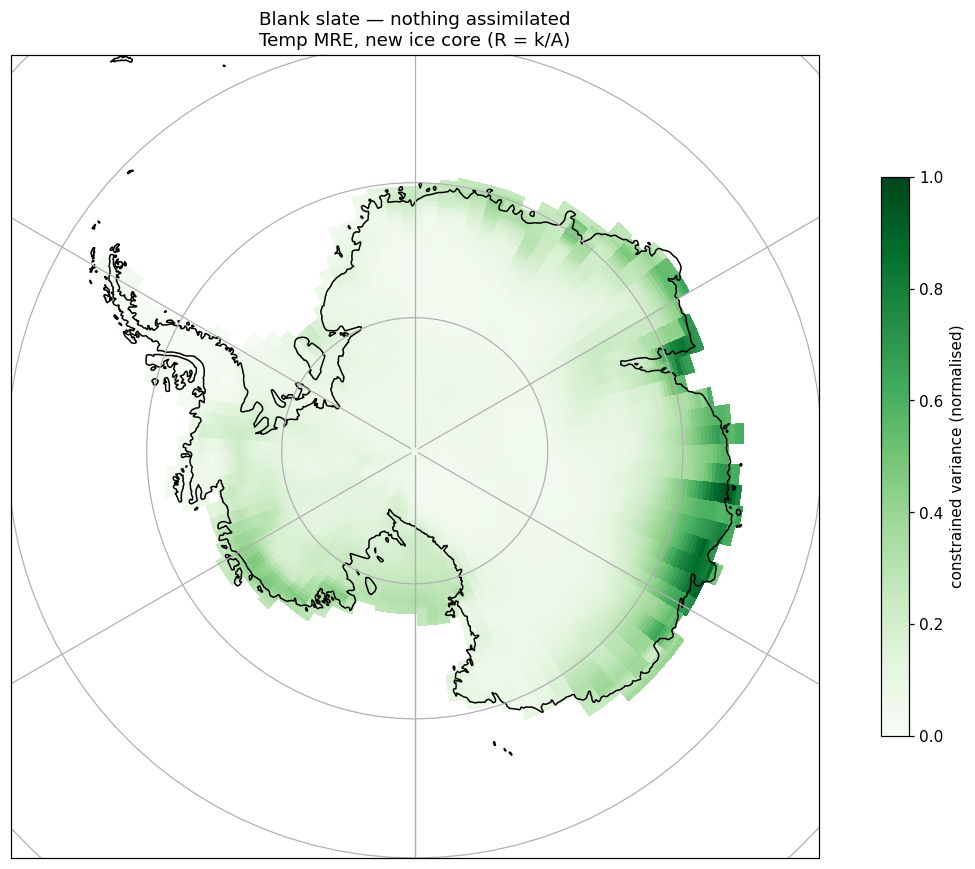

metric variance 0.31829
best site 5768 (-66.44, 113.75)  accum 1666 mm/yr  R 0.47 K^2
  constrains 28.30% of the metric variance


In [897]:
# Nothing assimilated: what a new ice core would constrain with no network.
# Swap R_ICE_CORE for R_AWS_ASSIM to ask the same question for a new station.
os_blank = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
dv_blank = os_blank.evaluate()

fig, ax, pm = plot_map(dv_blank / np.nanmax(dv_blank),
                       f'Blank slate — nothing assimilated\n'
                       f'{VARIABLE} {ENSEMBLE}, new ice core (R = k/A)',
                       show_aws=False)
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_blank))
print(f'metric variance {os_blank.J0var:.5f}')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f} mm/yr  R {R_ICE_CORE[k]:.2f} K^2')
print(f'  constrains {100*dv_blank.max()/os_blank.J0var:.2f}% of the metric variance')


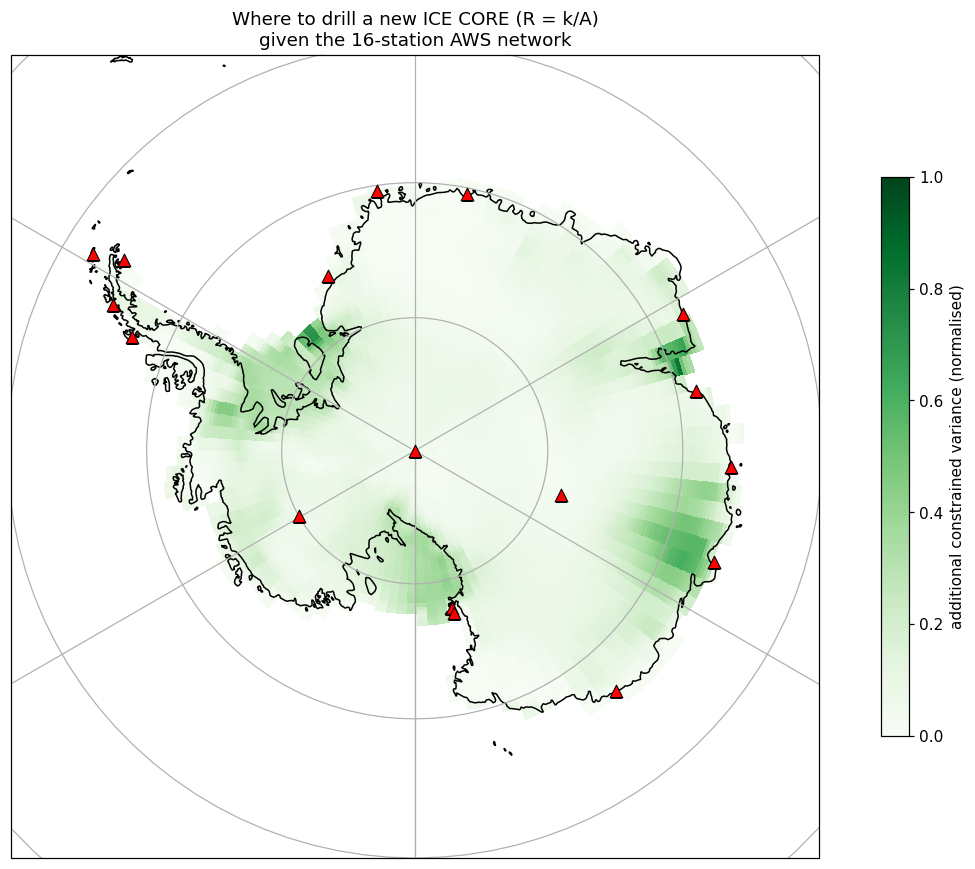

AWS network leaves 0.04805 of 0.31829 (84.9% constrained)
best site 5525 (-69.27, 71.25)  accum 490  R 1.59  adds 6.30% of what remains


In [898]:
J0, v0, dv_core, st_core, vr_core = res['ICE CORE']

fig, ax, pm = plot_map(dv_core / np.nanmax(dv_core),
                       f'Where to drill a new ICE CORE (R = k/A)\n'
                       f'given the {len(AWS_SITES)}-station AWS network')
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('additional constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_core))
print(f'AWS network leaves {v0:.5f} of {J0:.5f} ({100*(1-v0/J0):.1f}% constrained)')
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f}  R {R_ICE_CORE[k]:.2f}  '
      f'adds {100*np.nanmax(dv_core)/v0:.2f}% of what remains')


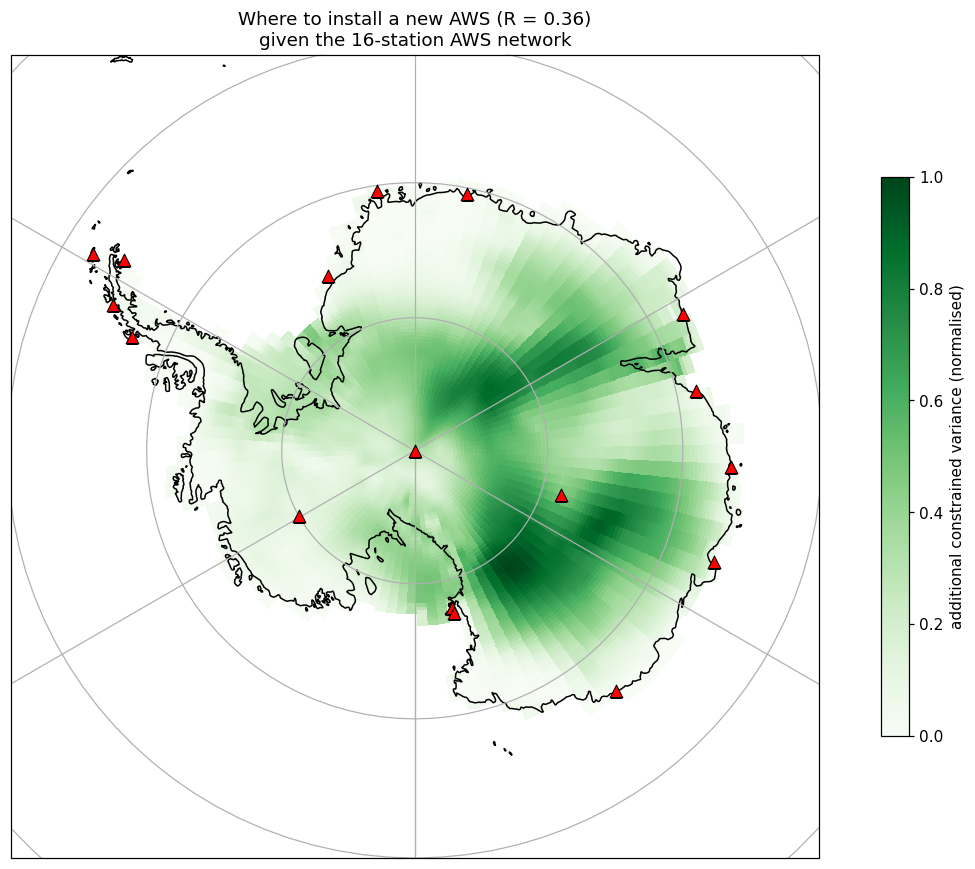

best site 3569 (-78.69, 141.25)  accum 30  adds 20.07% of what remains


In [899]:
J0, v0, dv_aws, st_aws, vr_aws = res['AWS']

fig, ax, pm = plot_map(dv_aws / np.nanmax(dv_aws),
                       f'Where to install a new AWS (R = {R_AWS_ASSIM})\n'
                       f'given the {len(AWS_SITES)}-station AWS network')
cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('additional constrained variance (normalised)')
plt.show()

k = int(np.nanargmax(dv_aws))
print(f'best site {k} ({site_lat[k]:.2f}, {site_lon[k]:.2f})  '
      f'accum {accum_rate[k]:.0f}  adds {100*np.nanmax(dv_aws)/v0:.2f}% of what remains')


AIS metric variance 0.31829; AWS network leaves 0.04805 (84.9% constrained)
      site    lat     lon   accum     R  alone_pct  cum_pct_remaining
rank                                                                 
1     5525 -69.27   71.25  489.89  1.59       6.30               6.30
2     3712 -78.69  320.00  298.71  2.60       4.70              10.27
3     5649 -68.32  112.50  553.42  1.40       3.91              13.71
4     4635 -74.92  282.50  672.01  1.16       2.89              16.11
5     5440 -70.21  107.50  179.01  4.34       3.48              18.43


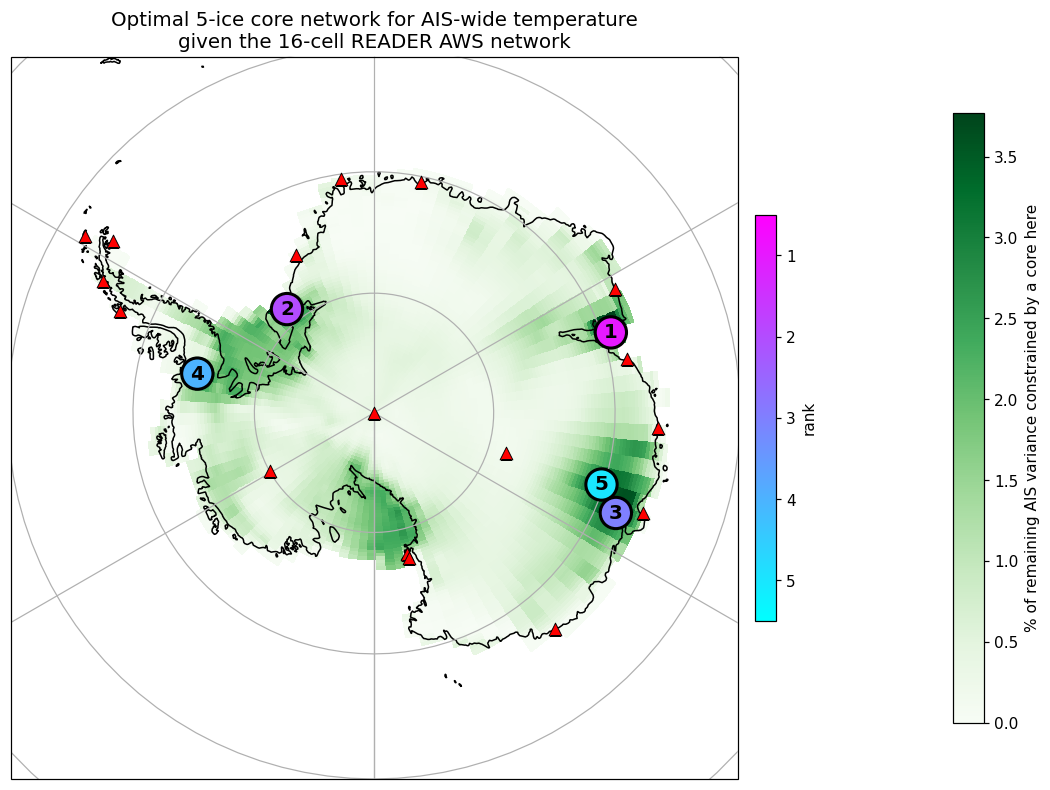

In [900]:
N_NEW      = 5
MIN_SEP_KM = 200.0     # 0 reproduces the raw algorithm, but sites 2 and 5 then
                       # land in adjacent cells (~50 km apart). 200 km costs only
                       # 13.78 -> 13.60% cumulative and gives distinct sites.

# --- run: new ice core (R = k/A), given the assimilated AWS network ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0                       # % of REMAINING variance, per site alone

o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st, vr = o2.run(N_NEW, min_sep_km=MIN_SEP_KM, verbose=False)

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1), 'site': st,
                    'lat': site_lat[st], 'lon': site_lon[st],
                    'accum': accum_rate[st], 'R': R_ICE_CORE[st],
                    'alone_pct': pct[st],
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())

# --- map ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL); ax.gridlines()

lm, am, g = interp_field(pct)
pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                   vmin=0, vmax=np.nanpercentile(pct, 99.8), zorder=0)

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

rk = np.arange(1, N_NEW+1); order = np.arange(N_NEW)[::-1]   # rank 1 drawn last
sc = ax.scatter(site_lon[st][order], site_lat[st][order], c=rk[order], s=420,
                lw=2, edgecolors='k', cmap=plt.cm.cool_r,
                vmin=.5, vmax=N_NEW+.5, transform=PL, zorder=4)
for r_, k in enumerate(st, 1):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=13, fontweight='bold', zorder=5)
ax.coastlines()

cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by a core here')
cbr = fig.colorbar(sc, ax=ax, shrink=.4, pad=.02, ticks=rk)
cbr.set_label('rank'); cbr.ax.invert_yaxis()
ax.set_title(f'Optimal {N_NEW}-ice core network for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


AIS metric variance 0.31829; AWS network leaves 0.04805 (84.9% constrained)
      site    lat     lon   accum  alone_pct  cum_pct_remaining
rank                                                           
1     3569 -78.69  141.25   29.51      20.07              20.07
2     2342 -82.46   47.50   27.15      17.66              31.97
3     4756 -73.98  110.00   47.56      18.04              42.12
4     3131 -80.58  313.75  137.99       8.45              49.21
5     3030 -80.58  187.50  133.00       7.69              54.35


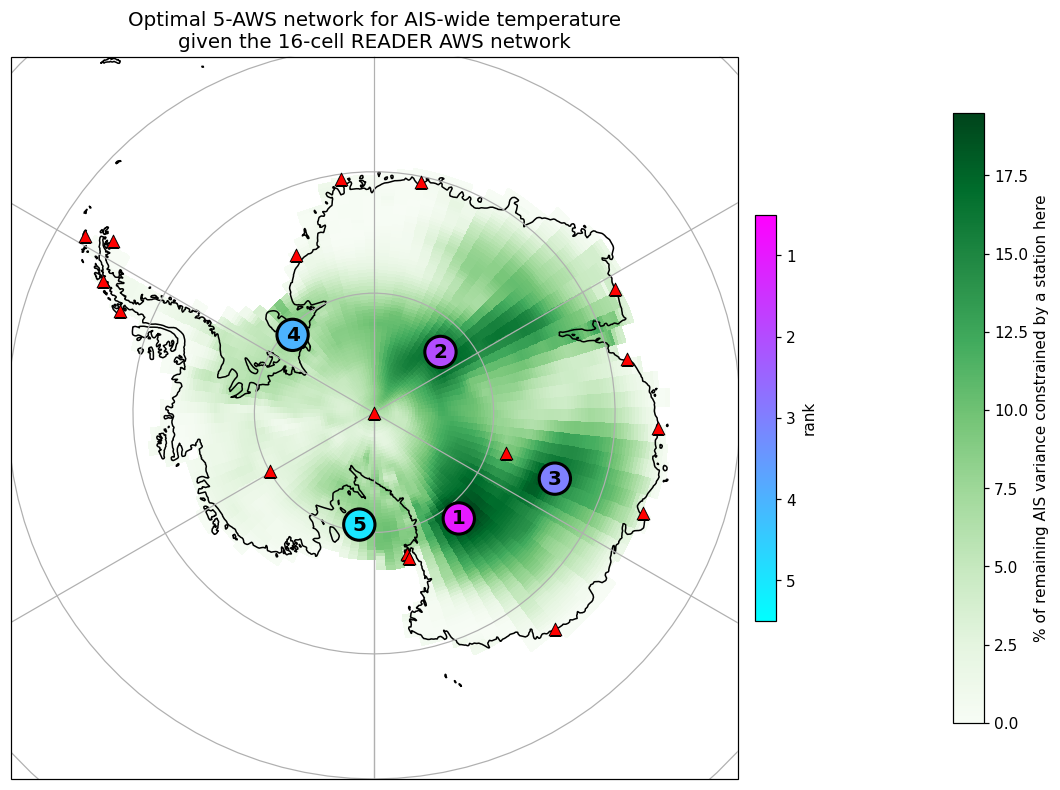

In [901]:
N_NEW      = 5
MIN_SEP_KM = 200.0     # for the AWS case this changes nothing -- the top 5 are
                       # already >200 km apart, unlike the ice-core case.

# --- run: new AWS station (R = R_AWS_ASSIM), given the assimilated network ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_AWS_ASSIM)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0                       # % of REMAINING variance, per site alone

o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_AWS_ASSIM)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st, vr = o2.run(N_NEW, min_sep_km=MIN_SEP_KM, verbose=False)

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1), 'site': st,
                    'lat': site_lat[st], 'lon': site_lon[st],
                    'accum': accum_rate[st],
                    'alone_pct': pct[st],
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())

# --- map ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL); ax.gridlines()

lm, am, g = interp_field(pct)
pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                   vmin=0, vmax=np.nanpercentile(pct, 99.8), zorder=0)

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

rk = np.arange(1, N_NEW+1); order = np.arange(N_NEW)[::-1]   # rank 1 drawn last
sc = ax.scatter(site_lon[st][order], site_lat[st][order], c=rk[order], s=420,
                lw=2, edgecolors='k', cmap=plt.cm.cool_r,
                vmin=.5, vmax=N_NEW+.5, transform=PL, zorder=4)
for r_, k in enumerate(st, 1):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=13, fontweight='bold', zorder=5)
ax.coastlines()

cb = fig.colorbar(pm, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by a station here')
cbr = fig.colorbar(sc, ax=ax, shrink=.4, pad=.02, ticks=rk)
cbr.set_label('rank'); cbr.ax.invert_yaxis()
ax.set_title(f'Optimal {N_NEW}-AWS network for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


80 cores -> 63 unique cells (median offset 27 km)

AIS metric variance 0.31829; AWS network leaves 0.04805 (84.9% constrained)
                core  site    lat     lon   accum     R  alone_pct
rank                                                              
1           Law Dome  5767 -66.44  112.50  844.72  0.92       2.32
2      Siple Station  4417 -75.86  276.25  631.87  1.23       1.72
3     Berkner Island  3419 -79.63  313.75  211.76  3.67       1.69
4           400th km  5430 -70.21   95.00  158.67  4.90       1.46
5         ITASE-01-5  4180 -76.81  271.25  456.73  1.70       1.24
sum of the five: 8.41%  (NOT what they would achieve together -- see the network cell)


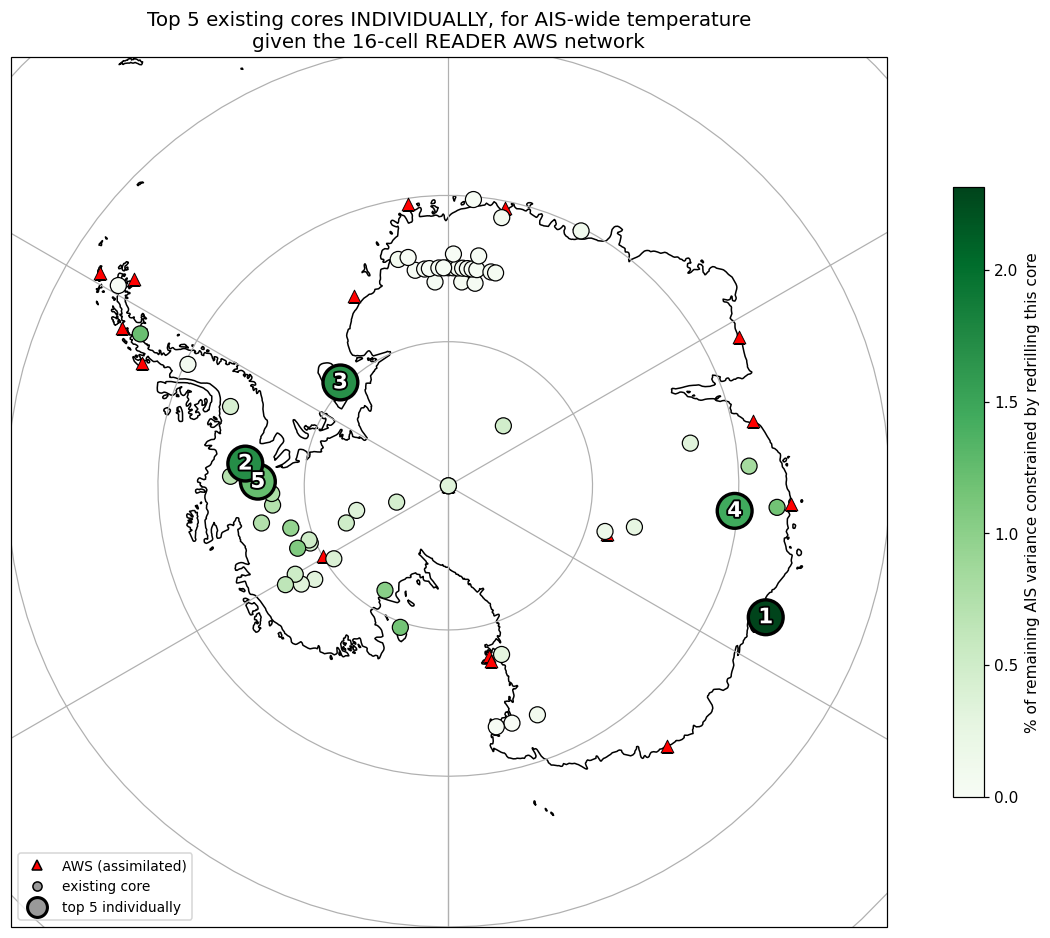

In [902]:
N_NEW = 5

# --- existing water-isotope core sites ---
cc = pd.read_csv(Path.home()/'DataFiles'/'WaterCoresCoords.csv', header=None,
                 names=['name', 'alt', 'lat', 'lon'])
cc['lat'] = cc.lat.astype(float)
cc['lon'] = np.mod(cc.lon.astype(float), 360.)
d = np.array([haversine_km(a, b, site_lat, site_lon) for a, b in zip(cc.lat, cc.lon)])
cc['site'] = d.argmin(1); cc['km'] = d.min(1)

CORE_SITES = sorted(set(cc.site))
core_mask  = np.zeros(N_POTENTIAL, bool); core_mask[CORE_SITES] = True
name_of = {}
for _, r in cc.iterrows():
    name_of.setdefault(int(r.site), r['name'])
print(f'{len(cc)} cores -> {len(CORE_SITES)} unique cells '
      f'(median offset {cc.km.median():.0f} km)')

# --- assimilate the AWS network, then evaluate every core ONCE ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0 = o.metric_variance()
dv = np.where(np.isfinite(o.evaluate()), o.evaluate(), np.nan)
pct = 100 * dv / v0

# Each core's value ASSIMILATED ALONE. These are the five best INDIVIDUAL
# choices -- they are NOT additive, since they overlap with one another.
st_alone = np.argsort(np.where(core_mask, pct, -np.inf))[::-1][:N_NEW]

print(f'\nAIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1),
                    'core': [name_of[int(s)] for s in st_alone], 'site': st_alone,
                    'lat': site_lat[st_alone], 'lon': site_lon[st_alone],
                    'accum': accum_rate[st_alone], 'R': R_ICE_CORE[st_alone],
                    'alone_pct': pct[st_alone]}).set_index('rank').round(2).to_string())
print(f'sum of the five: {pct[st_alone].sum():.2f}%  '
      f'(NOT what they would achieve together -- see the network cell)')

# --- map ---
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

CMAP = plt.cm.Greens
VMAX = float(np.nanmax(pct[CORE_SITES]))

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL)
ax.gridlines(); ax.coastlines()

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

other = [k for k in CORE_SITES if k not in set(st_alone)]
sc = ax.scatter(site_lon[other], site_lat[other], c=pct[other], s=110,
                cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.8,
                transform=PL, zorder=3)

order = np.arange(N_NEW)[::-1]              # paint worst-first, rank 1 on top
ax.scatter(site_lon[st_alone][order], site_lat[st_alone][order],
           c=pct[st_alone][order], s=520, cmap=CMAP, vmin=0, vmax=VMAX,
           edgecolors='k', lw=2.2, transform=PL, zorder=4)

for r_, k in zip(range(N_NEW, 0, -1), st_alone[::-1]):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=14, fontweight='bold', color='w',
                zorder=5 + (N_NEW - r_) * 0.01,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='k')])

cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by redrilling this core')
ax.legend(handles=[Line2D([], [], marker='^', ls='', c='red', mec='k',
                          label='AWS (assimilated)'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k',
                          label='existing core'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k', ms=13,
                          mew=2, label='top 5 individually')],
          loc='lower left', fontsize=9)
ax.set_title(f'Top {N_NEW} existing cores INDIVIDUALLY, for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


AIS metric variance 0.31829; AWS network leaves 0.04805 (84.9% constrained)
                core  site    lat     lon   accum     R  alone_pct  marginal_pct  cum_pct_remaining
rank                                                                                               
1           Law Dome  5767 -66.44  112.50  844.72  0.92       2.32          2.32               2.32
2     Berkner Island  3419 -79.63  313.75  211.76  3.67       1.69          1.68               4.00
3      Siple Station  4417 -75.86  276.25  631.87  1.23       1.72          1.50               5.49
4           400th km  5430 -70.21   95.00  158.67  4.90       1.46          1.27               6.76
5               RICE  3327 -79.63  198.75  168.78  4.60       1.17          1.11               7.88

network total: 7.88% of remaining variance
overlap with the individual top 5: 4/5


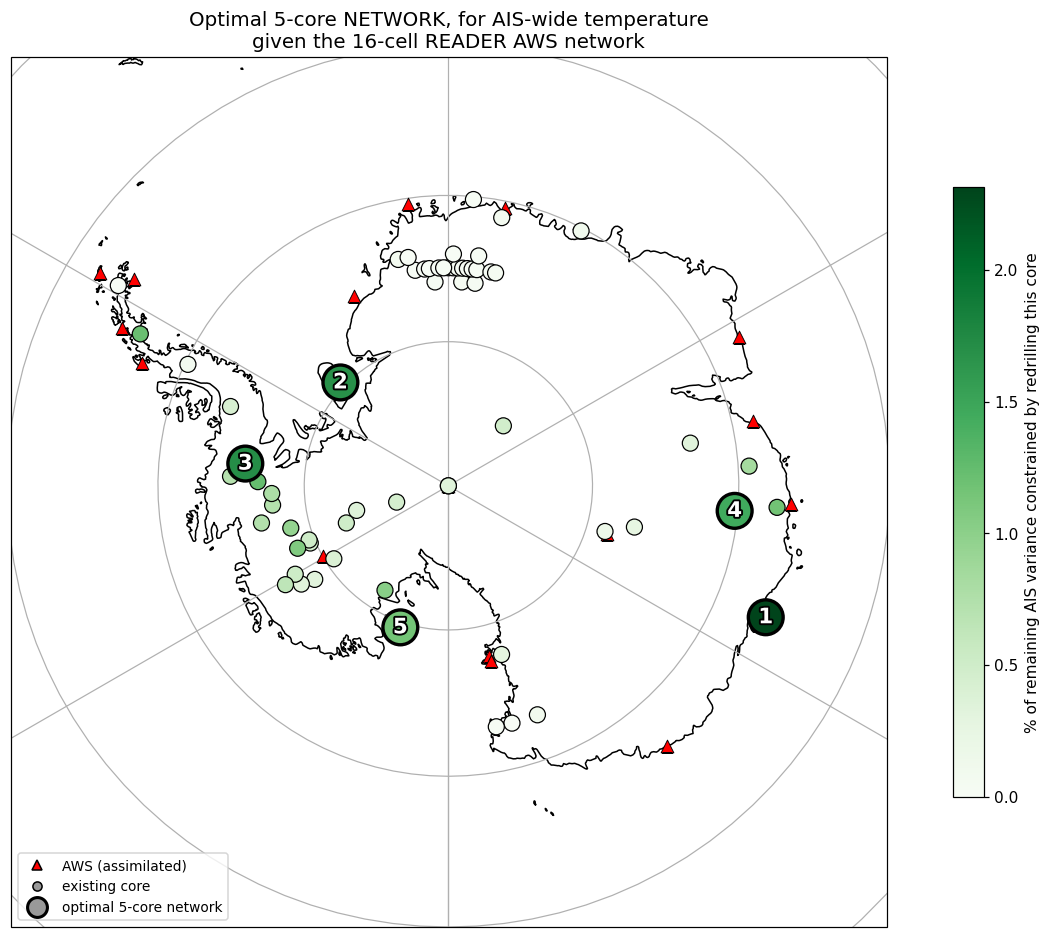

In [903]:
N_NEW = 5

# Greedy sequential: pick the best core, assimilate it, re-evaluate, repeat.
# Each site is credited only for what it adds beyond those already chosen, so
# this answers "which FIVE together" rather than "which five individually".
o2 = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
for i in AWS_SITES:
    o2.assimilate(int(i), Rval=R_AWS_ASSIM)
st_net, vr = o2.run(N_NEW, exclude=~core_mask, verbose=False)

marginal = -100 * np.diff(np.concatenate([[v0], vr])) / v0

print(f'AIS metric variance {J0:.5f}; AWS network leaves {v0:.5f} '
      f'({100*(1-v0/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1),
                    'core': [name_of[int(s)] for s in st_net], 'site': st_net,
                    'lat': site_lat[st_net], 'lon': site_lon[st_net],
                    'accum': accum_rate[st_net], 'R': R_ICE_CORE[st_net],
                    'alone_pct': pct[st_net],
                    'marginal_pct': marginal,
                    'cum_pct_remaining': 100*(1 - vr/v0)}).set_index('rank')
      .round(2).to_string())
print(f'\nnetwork total: {100*(1-vr[-1]/v0):.2f}% of remaining variance')
print(f'overlap with the individual top {N_NEW}: '
      f'{len(set(st_net) & set(st_alone))}/{N_NEW}')

# --- map (same colour scale as the individual cell, so the two are comparable) ---
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

CMAP = plt.cm.Greens
VMAX = float(np.nanmax(pct[CORE_SITES]))

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL)
ax.gridlines(); ax.coastlines()

ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=70, c='red',
           edgecolors='k', lw=.6, transform=PL, zorder=2)

other = [k for k in CORE_SITES if k not in set(st_net)]
sc = ax.scatter(site_lon[other], site_lat[other], c=pct[other], s=110,
                cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.8,
                transform=PL, zorder=3)

order = np.arange(N_NEW)[::-1]
ax.scatter(site_lon[st_net][order], site_lat[st_net][order],
           c=pct[st_net][order], s=520, cmap=CMAP, vmin=0, vmax=VMAX,
           edgecolors='k', lw=2.2, transform=PL, zorder=4)

for r_, k in zip(range(N_NEW, 0, -1), st_net[::-1]):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=14, fontweight='bold', color='w',
                zorder=5 + (N_NEW - r_) * 0.01,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='k')])

cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by redrilling this core')
ax.legend(handles=[Line2D([], [], marker='^', ls='', c='red', mec='k',
                          label='AWS (assimilated)'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k',
                          label='existing core'),
                   Line2D([], [], marker='o', ls='', c='0.6', mec='k', ms=13,
                          mew=2, label='optimal 5-core network')],
          loc='lower left', fontsize=9)
ax.set_title(f'Optimal {N_NEW}-core NETWORK, for AIS-wide temperature\n'
             f'given the {len(AWS_SITES)}-cell READER AWS network', fontsize=13)
plt.show()


In [904]:
# The CCSM4 grid has no basin field, so sample the IMBIE basins and topography
# from the RACMO ANT11 mask at each site location (nearest neighbour on the
# sphere). Median distance is 4.3 km, so the lookup is effectively exact.
#
# NOTE: do not name anything _i / _ii / _iii / _ / __ here -- IPython reserves
# those for input/output history and overwrites them after every cell.
from scipy.spatial import cKDTree

assert site_lat.size == N_POTENTIAL, (
    f'site_lat has {site_lat.size} entries but N_POTENTIAL is {N_POTENTIAL} -- '
    're-run the site-coordinates cell, then this one.')

ANT11        = Path.home()/'DataFiles'/'ANT11_masks.nc'
GROUNDED_NPY = Path.home()/'DataFiles'/'ANT11_grounded_mask.npy'

ant11      = xr.open_dataset(ANT11)
ant11_ice  = ant11['Icesheet_Only'].values > 0.5
ant11_B    = ant11['Basins'].values[ant11_ice]
ant11_topo = ant11['Topography'].values[ant11_ice]
ant11_lat  = ant11['lat'].values[ant11_ice]
ant11_lon  = np.mod(ant11['lon'].values, 360.)[ant11_ice]
ant11_gr   = np.load(GROUNDED_NPY)[ant11_ice]

def to_xyz(la, lo):
    la, lo = np.radians(la), np.radians(lo)
    return np.stack([np.cos(la)*np.cos(lo), np.cos(la)*np.sin(lo), np.sin(la)], -1)

nn_dist, nn_idx = cKDTree(to_xyz(ant11_lat, ant11_lon)).query(
    to_xyz(site_lat, site_lon))
nn_km = 2*6371.0088*np.arcsin(np.clip(nn_dist/2, 0, 1))

site_basin          = ant11_B[nn_idx]
site_grounded_imbie = ant11_gr[nn_idx]
site_elev           = ant11_topo[nn_idx]      # <-- this is what was missing
too_far             = nn_km > 150

# IMBIE basins grouped by centroid geography. Verified areas on the native
# ANT11 grid: EAIS 10.13, WAIS 1.88, AP 0.31 M km^2.
REGIONS = {
    'EAIS': [2, 4, 5, 7, 9, 12, 13, 14, 15, 17],
    'WAIS': [1, 18, 20, 21, 23],
    'AP':   [24, 25, 27],
}
region_mask = {rn: (np.isin(site_basin, ids) & site_grounded_imbie & ~too_far)
               for rn, ids in REGIONS.items()}

wts = np.cos(np.deg2rad(site_lat))
print(f'nearest ANT11 cell: median {np.median(nn_km):.1f} km, max {nn_km.max():.0f} km '
      f'({too_far.sum()} site(s) >150 km excluded)')
for rn, rm_ in region_mask.items():
    print(f'  {rn:5s} {rm_.sum():5d} sites, '
          f'{100*wts[rm_].sum()/wts.sum():5.1f}% of cos-lat weight')
print(f'  unassigned: {N_POTENTIAL - sum(v.sum() for v in region_mask.values())} '
      f'(ice shelves and cells outside the basins)')
print(f'site elevation: {site_elev.min():.0f}-{site_elev.max():.0f} m, '
      f'median {np.median(site_elev):.0f} m')


nearest ANT11 cell: median 4.3 km, max 117 km (0 site(s) >150 km excluded)
  EAIS   4529 sites,  73.0% of cos-lat weight
  WAIS    698 sites,  13.7% of cos-lat weight
  AP       69 sites,   2.4% of cos-lat weight
  unassigned: 497 (ice shelves and cells outside the basins)
site elevation: 5-4072 m, median 2545 m


In [905]:
metrics = {rn: build_metric(Ye, mask=rm_) for rn, rm_ in region_mask.items()}
for rn, Jr in metrics.items():
    print(f'{rn:5s} mean {Jr.mean():7.2f} K   sd {Jr.std(ddof=1):.3f} K   '
          f'variance {unbias*((Jr-Jr.mean())**2).sum():.5f}')


EAIS  mean    0.00 K   sd 0.604 K   variance 0.36525
WAIS  mean   -0.00 K   sd 0.750 K   variance 0.56298
AP    mean    0.00 K   sd 0.859 K   variance 0.73845


In [906]:
def experiment_for(Jr, candidate_R):
    """Pre-assimilate the AWS network, then evaluate every site against Jr."""
    o = OptimalSensor(Jr, Ye[:N_POTENTIAL], candidate_R)
    J0 = o.J0var
    for i in AWS_SITES:
        o.assimilate(int(i), Rval=R_AWS_ASSIM)
    dv = o.evaluate()
    return J0, o.metric_variance(), np.where(np.isfinite(dv), dv, np.nan)

reg_res = {}
for rn in REGIONS:
    for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
        J0, v0, dv = experiment_for(metrics[rn], cand)
        reg_res[(rn, lbl)] = (J0, v0, dv)
        k = int(np.nanargmax(dv))
        print(f'{rn:5s} {lbl:9s}  AWS net {100*(1-v0/J0):5.1f}%  |  '
              f'best {k:5d} ({site_lat[k]:7.2f}, {site_lon[k]:7.2f})  '
              f'accum {accum_rate[k]:7.1f}  ->  +{100*np.nanmax(dv)/v0:5.2f}% of remaining')


EAIS  ICE CORE   AWS net  85.2%  |  best  5525 ( -69.27,   71.25)  accum   489.9  ->  + 5.59% of remaining
EAIS  AWS        AWS net  85.2%  |  best  2637 ( -81.52,   56.25)  accum    20.9  ->  +24.06% of remaining
WAIS  ICE CORE   AWS net  70.6%  |  best  4807 ( -73.98,  241.25)  accum  1148.4  ->  +24.27% of remaining
WAIS  AWS        AWS net  70.6%  |  best  4393 ( -75.86,  246.25)  accum   731.6  ->  +32.51% of remaining
AP    ICE CORE   AWS net  72.2%  |  best  5014 ( -73.04,  288.75)  accum   999.8  ->  +31.49% of remaining
AP    AWS        AWS net  72.2%  |  best  5184 ( -72.09,  290.00)  accum   614.6  ->  +52.14% of remaining


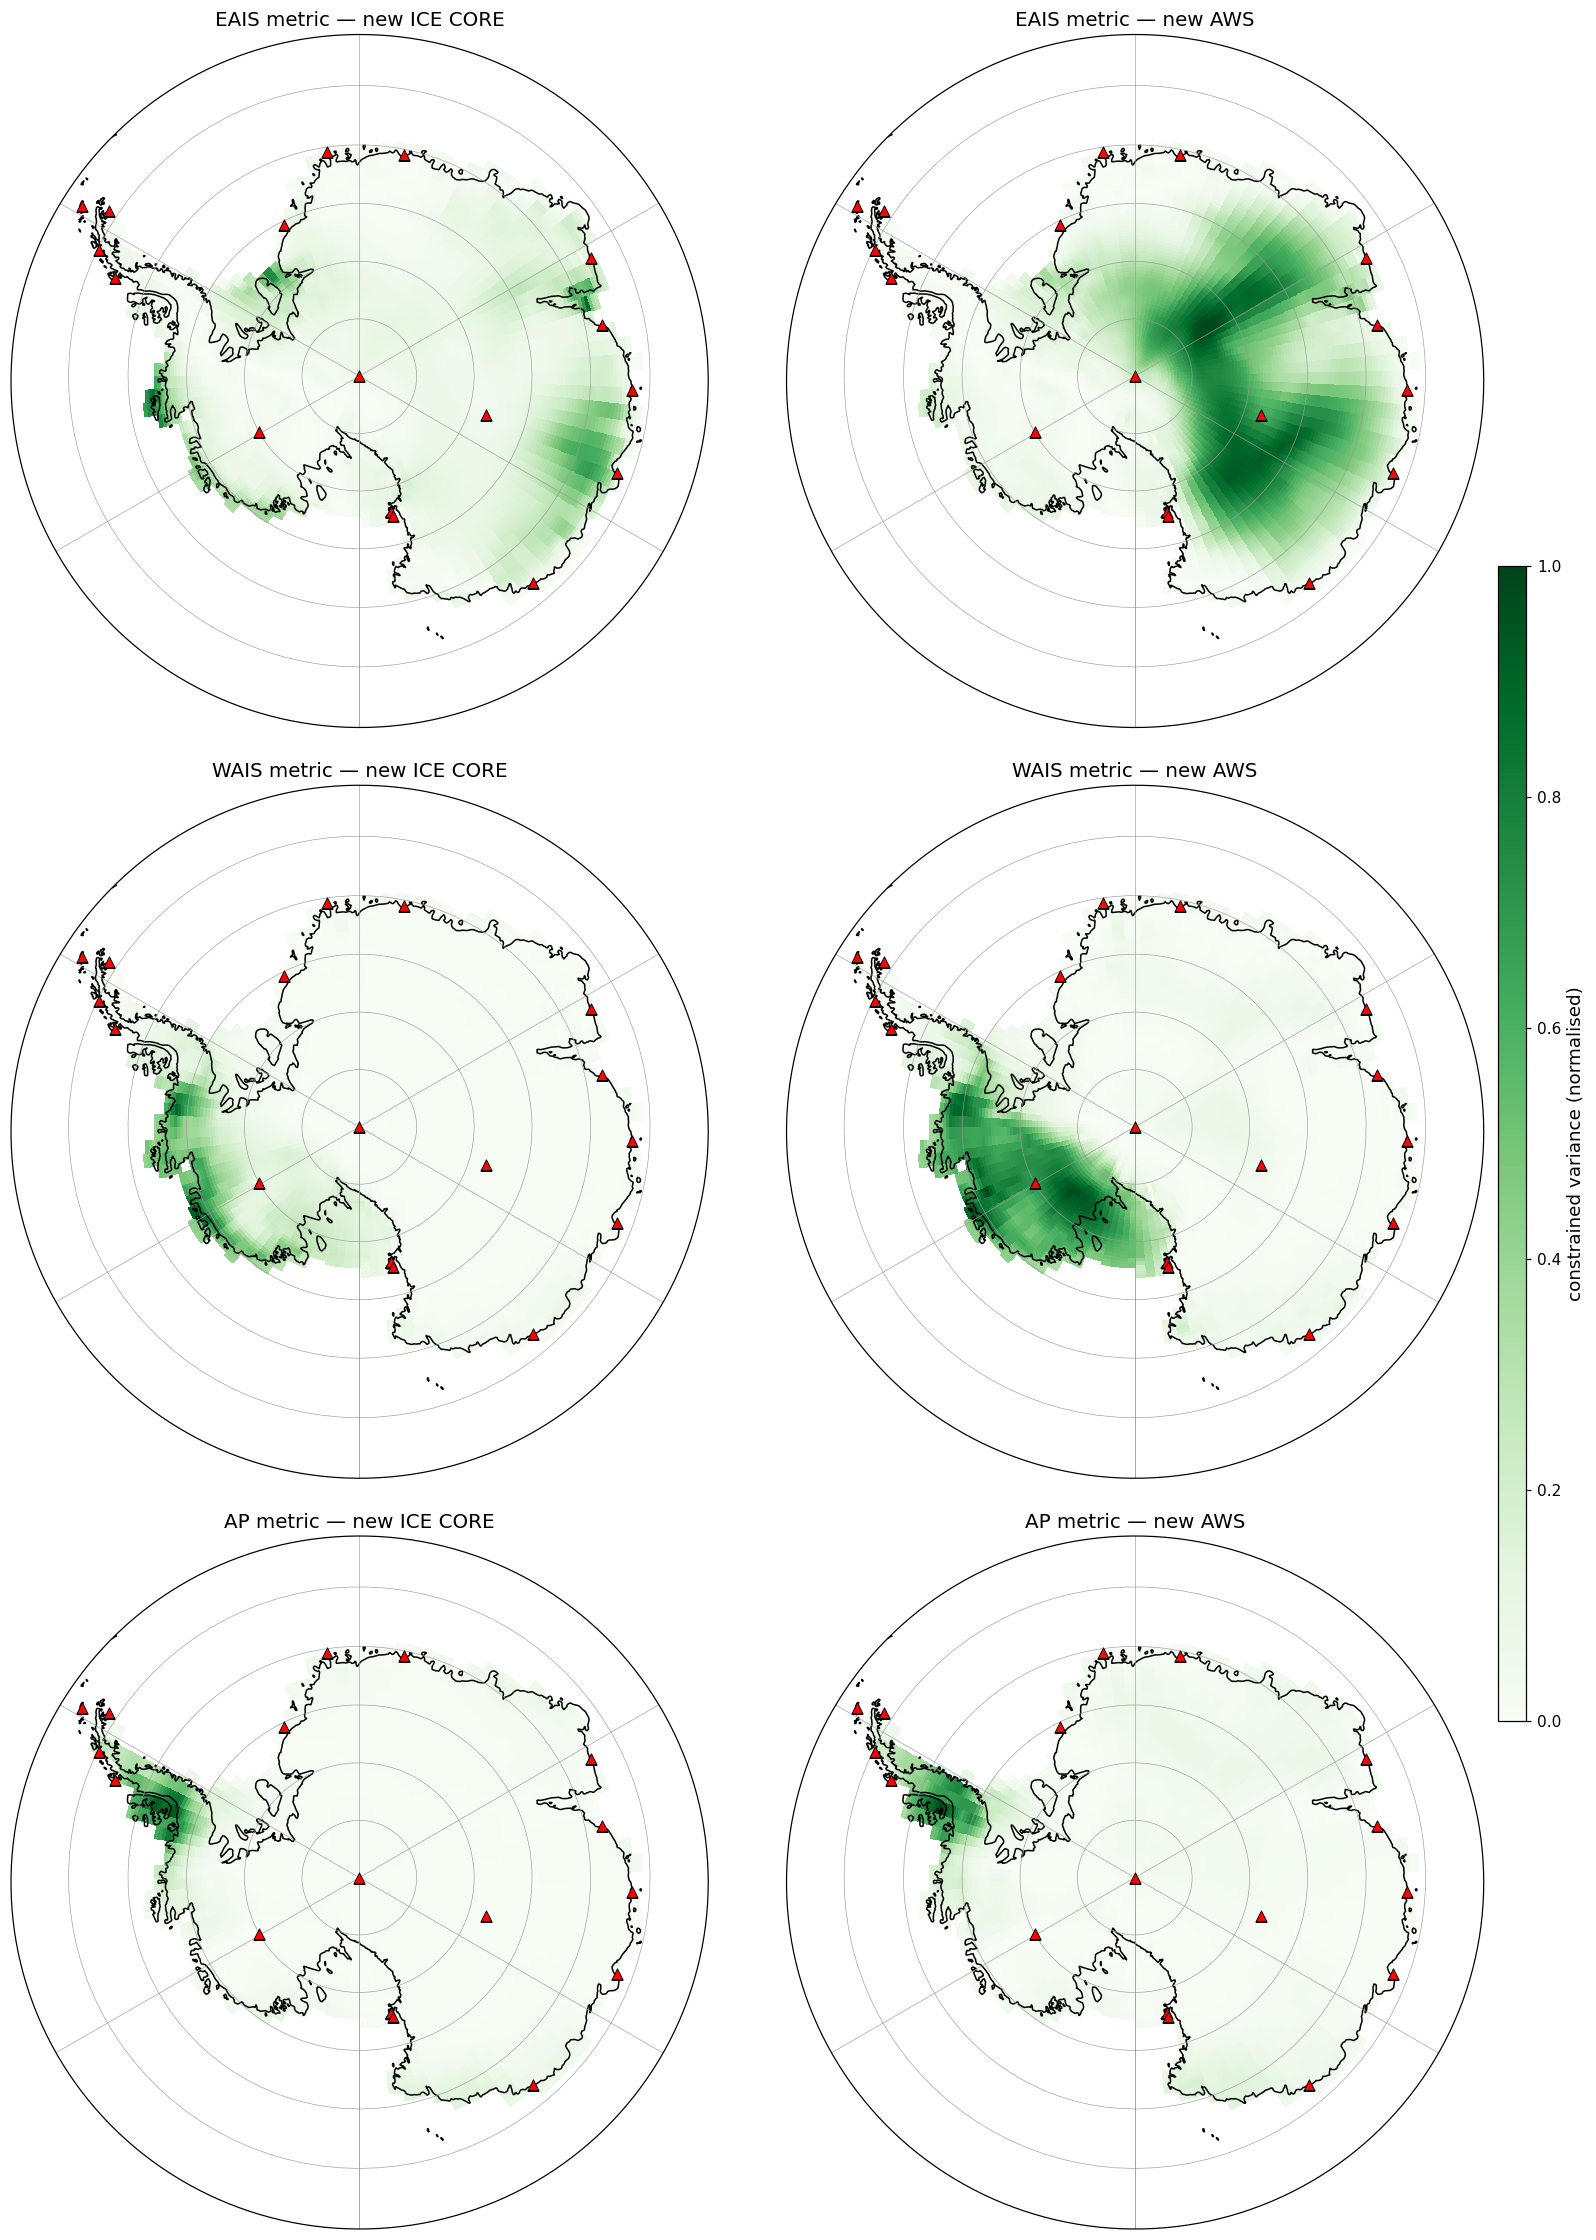

In [907]:
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(15, 21))

for r, rn in enumerate(REGIONS):
    for c, lbl in enumerate(['ICE CORE', 'AWS']):
        J0, v0, dv = reg_res[(rn, lbl)]
        ax = fig.add_axes([0.02 + c*0.47, 0.68 - r*0.325, 0.44, 0.30],
                          projection=SP)
        ax.set_extent([-180, 180, -90, -60], PL)
        th = np.linspace(0, 2*np.pi, 200)
        ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                        transform=ax.transAxes)
        ax.gridlines(linewidth=.4, color='0.6')

        lm, am, g = interp_field(dv/np.nanmax(dv))
        pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                           vmin=0, vmax=1, zorder=0)

        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=55, c='red',
                   edgecolors='k', lw=.6, transform=PL, zorder=3)
        ax.coastlines()
        ax.set_title(f'{rn} metric — new {lbl}', fontsize=13)

cax = fig.add_axes([0.93, 0.25, 0.017, 0.5])
cb = fig.colorbar(pm, cax=cax)
cb.set_label('constrained variance (normalised)', fontsize=12)
plt.show()


In [908]:
# --- PAGES Ant-2K regions (Stenni et al. 2017), port of regions_Ant2K.m ---
# site_elev now comes from region cell A, so this cell no longer computes it.
PLATEAU_ALTI, PENI, WED, B_AI = 2000.0, -74.0, 330.0, 67.0

_VIC = """-85 150
-84 150
-83 149
-82 148
-81 147
-80 149
-79 150
-78 150
-77 150
-76 155
-75 160
-74 160
-73 160
-72 160
-71 160
-70 160
-69 160
-68 160
-67 160
-66 160
-65 160
-64 160
-63 160"""
vic_tab = np.array([[float(x) for x in l.split()] for l in _VIC.strip().splitlines()])
vic_ord = np.argsort(vic_tab[:, 0])
lats_v, vlim = vic_tab[vic_ord, 0], vic_tab[vic_ord, 1]

def regions_ant2k(lat, lon, elevi, edml_zero=False):
    """Rules applied in order, later ones overwriting -- as in the MATLAB.
    edml_zero=True reproduces the original's region-0 bug; False is the fix."""
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    elevi = np.asarray(elevi, float); sh = lat.shape
    vlat = lat.ravel(); vlon = np.mod(lon.ravel(), 360.); ve = elevi.ravel()
    reg = np.full(vlat.shape, np.nan)
    vll = np.interp(vlat, lats_v, vlim, left=np.nan, right=np.nan)
    with np.errstate(invalid='ignore'):
        reg[(vlon < 145) & (ve > PLATEAU_ALTI)] = 1
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlon < vll)] = 1
        reg[(vlon >= 145) & (vlon < 350) & (vlat < -84) & (ve >= 0)] = 1
        f = 0. if edml_zero else 1.
        reg[(vlon < 30) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon >= 300) & (ve > PLATEAU_ALTI)] = f
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat > -76) & (ve >= 0)] = 7
        reg[(vlon > 0) & (vlon < B_AI) & (ve < PLATEAU_ALTI)] = 7
        reg[(vlon > WED) & (ve < PLATEAU_ALTI) & (vlat < -75) & (ve >= 0)] = 3
        reg[(vlon >= 300) & (vlon < WED) & (ve < PLATEAU_ALTI)] = 3
        reg[(vlon >= B_AI) & (vlon < 145) & (ve < PLATEAU_ALTI)] = 2
        reg[(vlon >= 145) & (vlon < 160) & (ve >= 0) & (vlon < vll)
            & (ve < PLATEAU_ALTI) & (vlat > -72)] = 2
        reg[(vlon >= 145) & (vlon < 190) & (ve >= 0) & (vlat < -74) & (vlon > vll)] = 6
        reg[(vlon >= 160) & (vlon < 190) & (ve >= 0) & (vlon > vll)] = 6
        reg[(vlon >= 190) & (vlon < 280) & (vlat > -85) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 300) & (vlat > -85) & (vlat < PENI+.5) & (ve >= 0)] = 5
        reg[(vlon >= 280) & (vlon < 305) & (vlat > PENI) & (ve >= 0)] = 4
    return reg.reshape(sh)

P2K_NAMES = {1: 'East Antarctic Plateau', 2: 'Wilkes Land Coast',
             3: 'Weddell Sea Coast', 4: 'Antarctic Peninsula', 5: 'WAIS',
             6: 'Victoria Land / Ross Sea', 7: 'Dronning Maud Land Coast'}

site_region = regions_ant2k(site_lat, site_lon, site_elev, edml_zero=False)
p2k_mask = {v: ((site_region == v) & site_grounded_imbie & ~too_far)
            for v in range(1, 8)}

print(f'{"region":32s} {"sites":>6s} {"weight":>8s}')
for v, nm in P2K_NAMES.items():
    mk_ = p2k_mask[v]
    print(f'{v} {nm:30s} {mk_.sum():6d} {100*wts[mk_].sum()/wts.sum():7.1f}%')
print(f'unassigned or ungrounded: '
      f'{int((~np.isin(site_region, list(range(1,8))) | ~site_grounded_imbie).sum())}')


region                            sites   weight
1 East Antarctic Plateau           3677    52.4%
2 Wilkes Land Coast                 183     6.9%
3 Weddell Sea Coast                 276     4.4%
4 Antarctic Peninsula                70     2.4%
5 WAIS                              771    14.4%
6 Victoria Land / Ross Sea          146     2.8%
7 Dronning Maud Land Coast          157     5.4%
unassigned or ungrounded: 513


In [909]:
p2k_metrics = {v: build_metric(Ye, mask=p2k_mask[v]) for v in range(1, 8)}

p2k_res = {}
print(f'{"region":32s} {"sd":>6s} {"AWSnet":>7s} {"core+%":>7s} {"aws+%":>7s}  best core site')
for v, nm in P2K_NAMES.items():
    Jr = p2k_metrics[v]
    for lbl, cand in [('ICE CORE', R_ICE_CORE), ('AWS', R_AWS_ASSIM)]:
        p2k_res[(v, lbl)] = experiment_for(Jr, cand)
    J0, v0, dvc = p2k_res[(v, 'ICE CORE')]
    _,  _,  dva = p2k_res[(v, 'AWS')]
    k = int(np.nanargmax(dvc))
    print(f'{v} {nm:30s} {Jr.std(ddof=1):6.3f} {100*(1-v0/J0):6.1f}% '
          f'{100*np.nanmax(dvc)/v0:6.2f}% {100*np.nanmax(dva)/v0:6.2f}%  '
          f'({site_lat[k]:7.2f}, {site_lon[k]:7.2f}) A={accum_rate[k]:.0f}')


region                               sd  AWSnet  core+%   aws+%  best core site
1 East Antarctic Plateau          0.651   83.5%   4.30%  27.62%  ( -72.09,  262.50) A=1174
2 Wilkes Land Coast               0.682   85.8%  13.62%  29.50%  ( -67.38,  127.50) A=1124
3 Weddell Sea Coast               0.777   44.2%  26.99%  65.56%  ( -78.69,  320.00) A=299
4 Antarctic Peninsula             0.859   72.0%  31.39%  51.95%  ( -73.04,  288.75) A=1000
5 WAIS                            0.741   70.3%  23.73%  33.21%  ( -73.98,  241.25) A=1148
6 Victoria Land / Ross Sea        0.701   69.0%   6.20%  35.52%  ( -78.69,  162.50) A=295
7 Dronning Maud Land Coast        0.565   81.9%   9.70%  25.04%  ( -67.38,   58.75) A=484


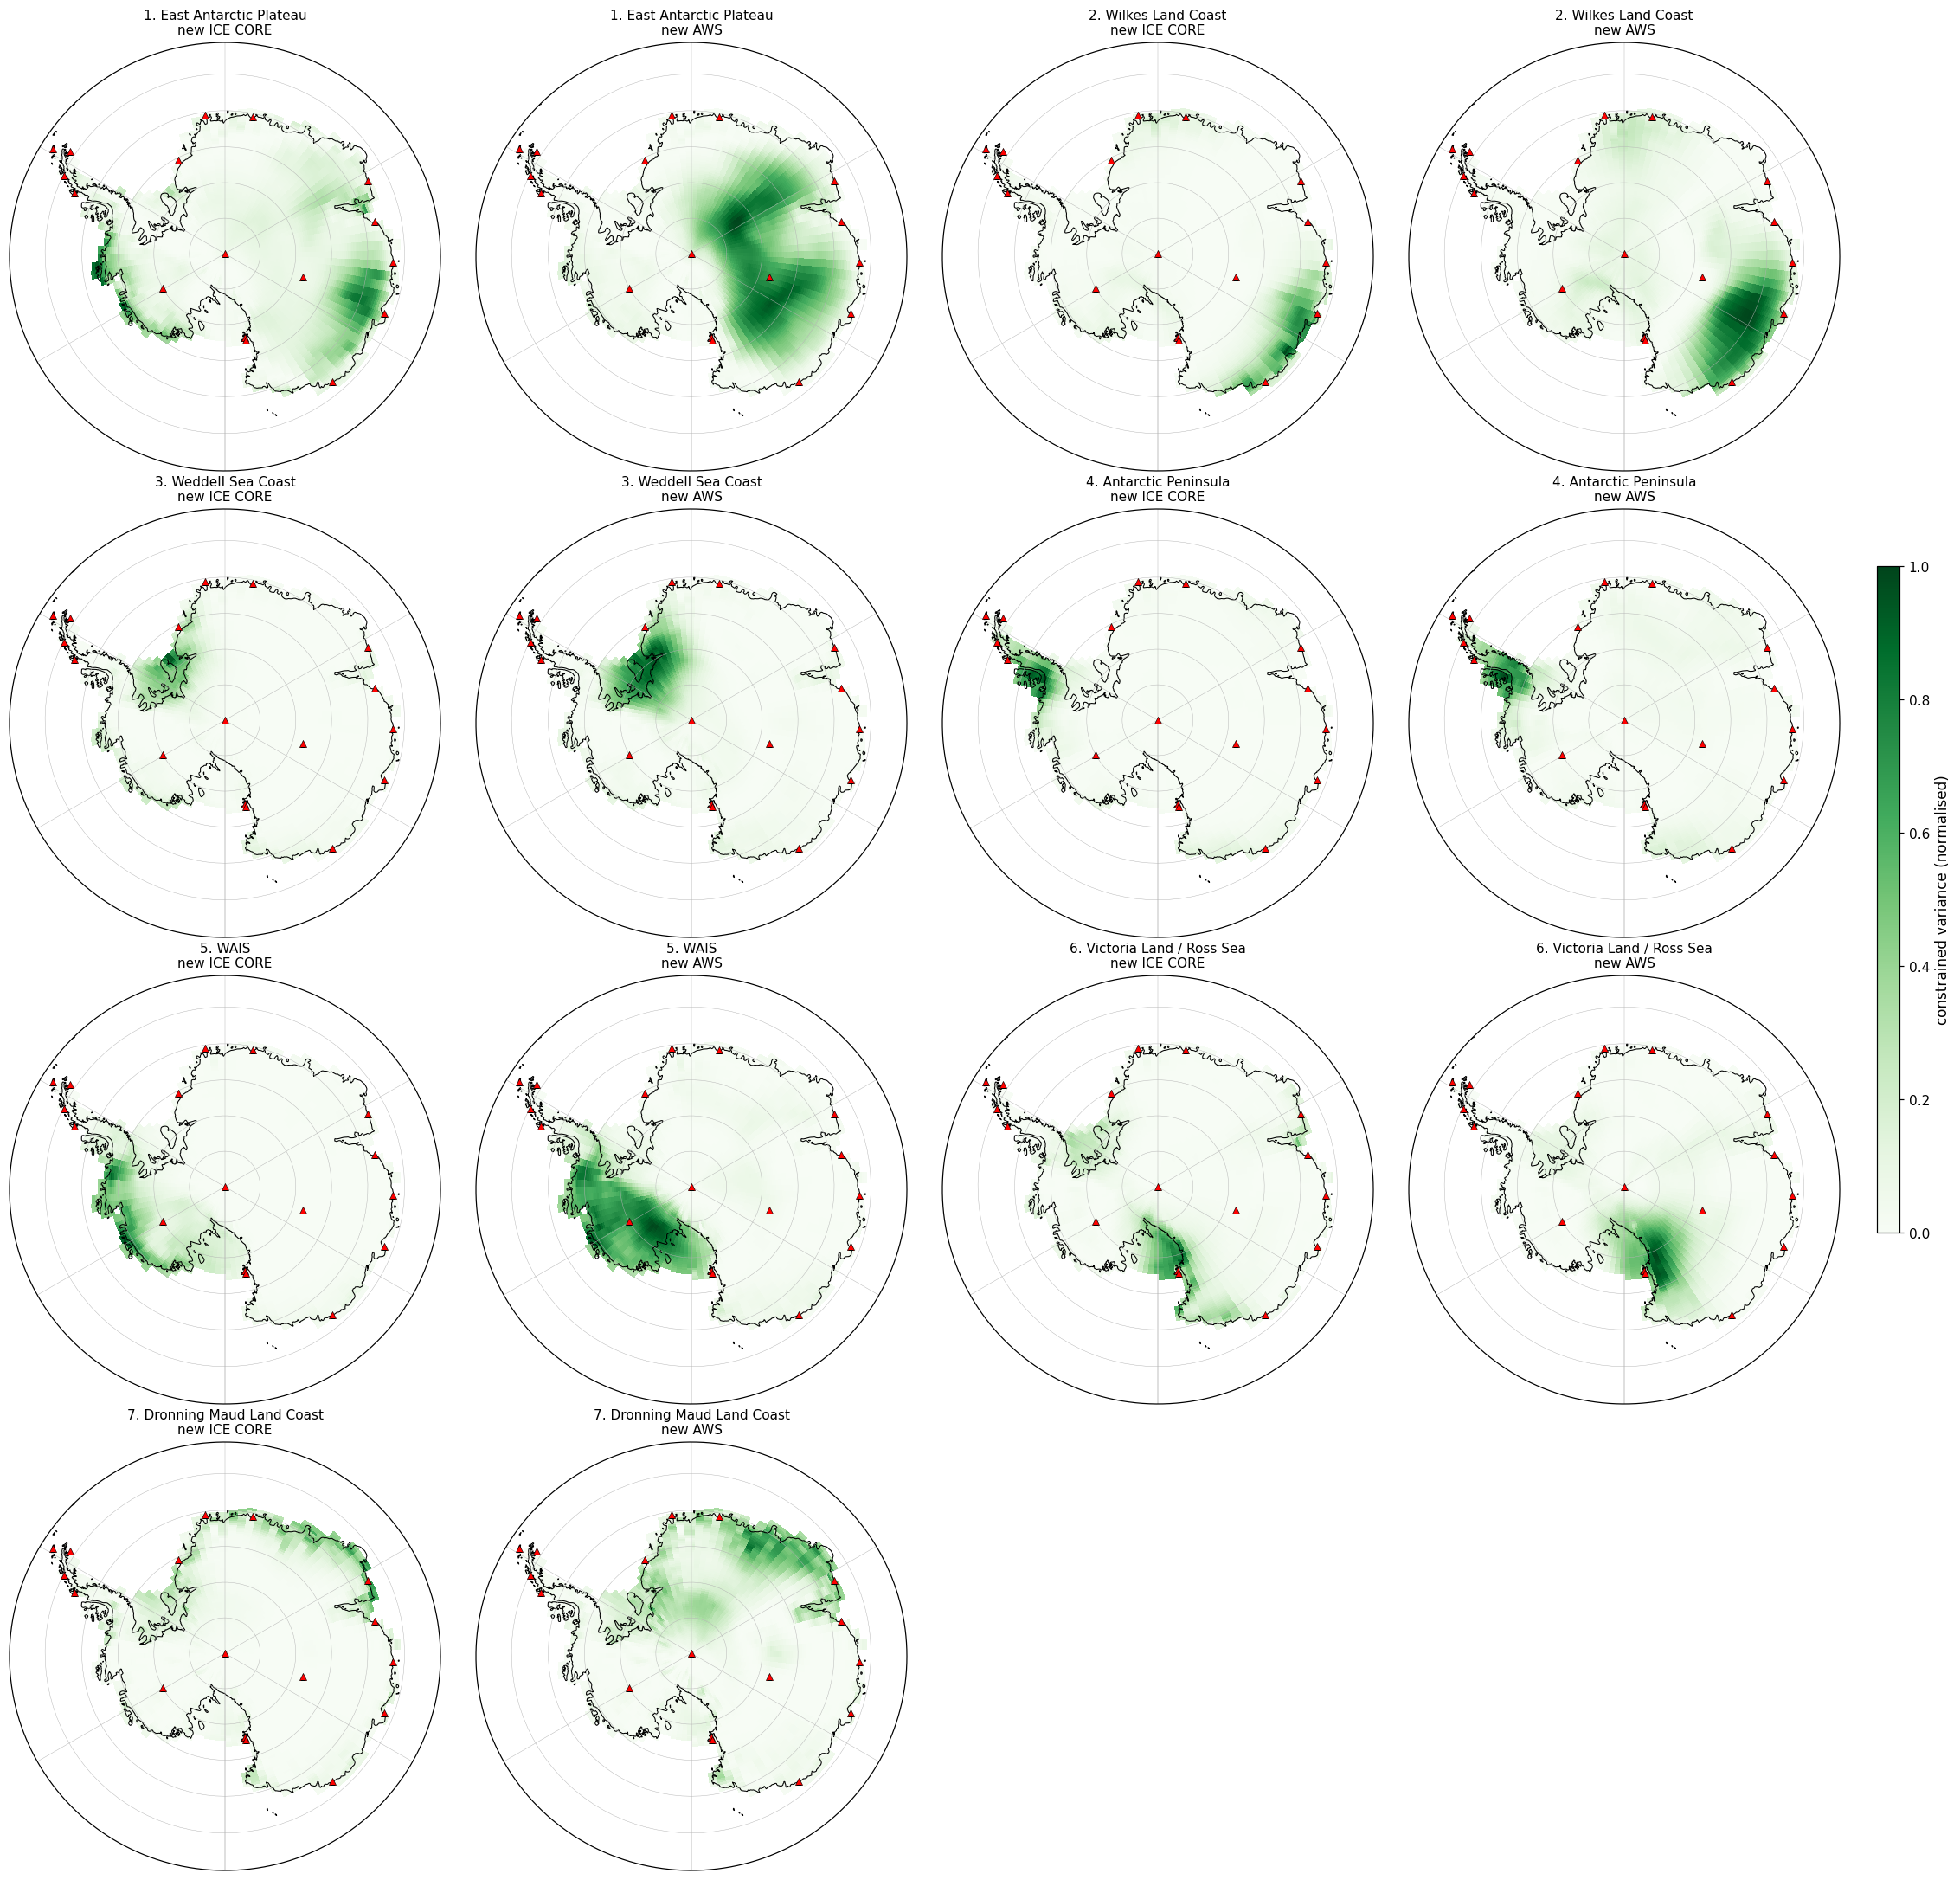

In [910]:
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(20, 20))

for idx, v in enumerate(range(1, 8)):
    for c, lbl in enumerate(['ICE CORE', 'AWS']):
        p = idx*2 + c
        r_, cc = divmod(p, 4)
        ax = fig.add_axes([0.01 + cc*0.245, 0.75 - r_*0.245, 0.235, 0.225],
                          projection=SP)
        ax.set_extent([-180, 180, -90, -60], PL)
        th = np.linspace(0, 2*np.pi, 200)
        ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                        transform=ax.transAxes)
        ax.gridlines(linewidth=.3, color='0.7')

        J0, v0, dv = p2k_res[(v, lbl)]
        lm, am, g = interp_field(dv/np.nanmax(dv))
        pm = ax.pcolormesh(lm, am, g, transform=PL, cmap=plt.cm.Greens,
                           vmin=0, vmax=1, zorder=0)
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=28, c='red',
                   edgecolors='k', lw=.4, transform=PL, zorder=3)
        ax.coastlines(linewidth=.7)
        ax.set_title(f'{v}. {P2K_NAMES[v]}\nnew {lbl}', fontsize=10)

cax = fig.add_axes([0.995, 0.35, 0.012, 0.35])
cb = fig.colorbar(pm, cax=cax)
cb.set_label('constrained variance (normalised)', fontsize=11)
plt.show()


80 cores -> 63 unique cells

                                              core    lat     lon    accum     R  alone_pct
region                     rank                                                            
1 East Antarctic Plateau   1              400th km -70.21   95.00   158.67  4.90       1.99
                           2              Law Dome -66.44  112.50   844.72  0.92       1.44
                           3                   DIV -76.81  258.75   565.92  1.37       0.95
2 Wilkes Land Coast        1              Law Dome -66.44  112.50   844.72  0.92       7.37
                           2              105th km -67.38   93.75   521.80  1.49       2.27
                           3               DML S20 -70.21    5.00   522.06  1.49       1.94
3 Weddell Sea Coast        1        Berkner Island -79.63  313.75   211.76  3.67      12.44
                           2               DML E91 -73.98  347.50   328.75  2.36       2.99
                           3     Whitehall Glacier 

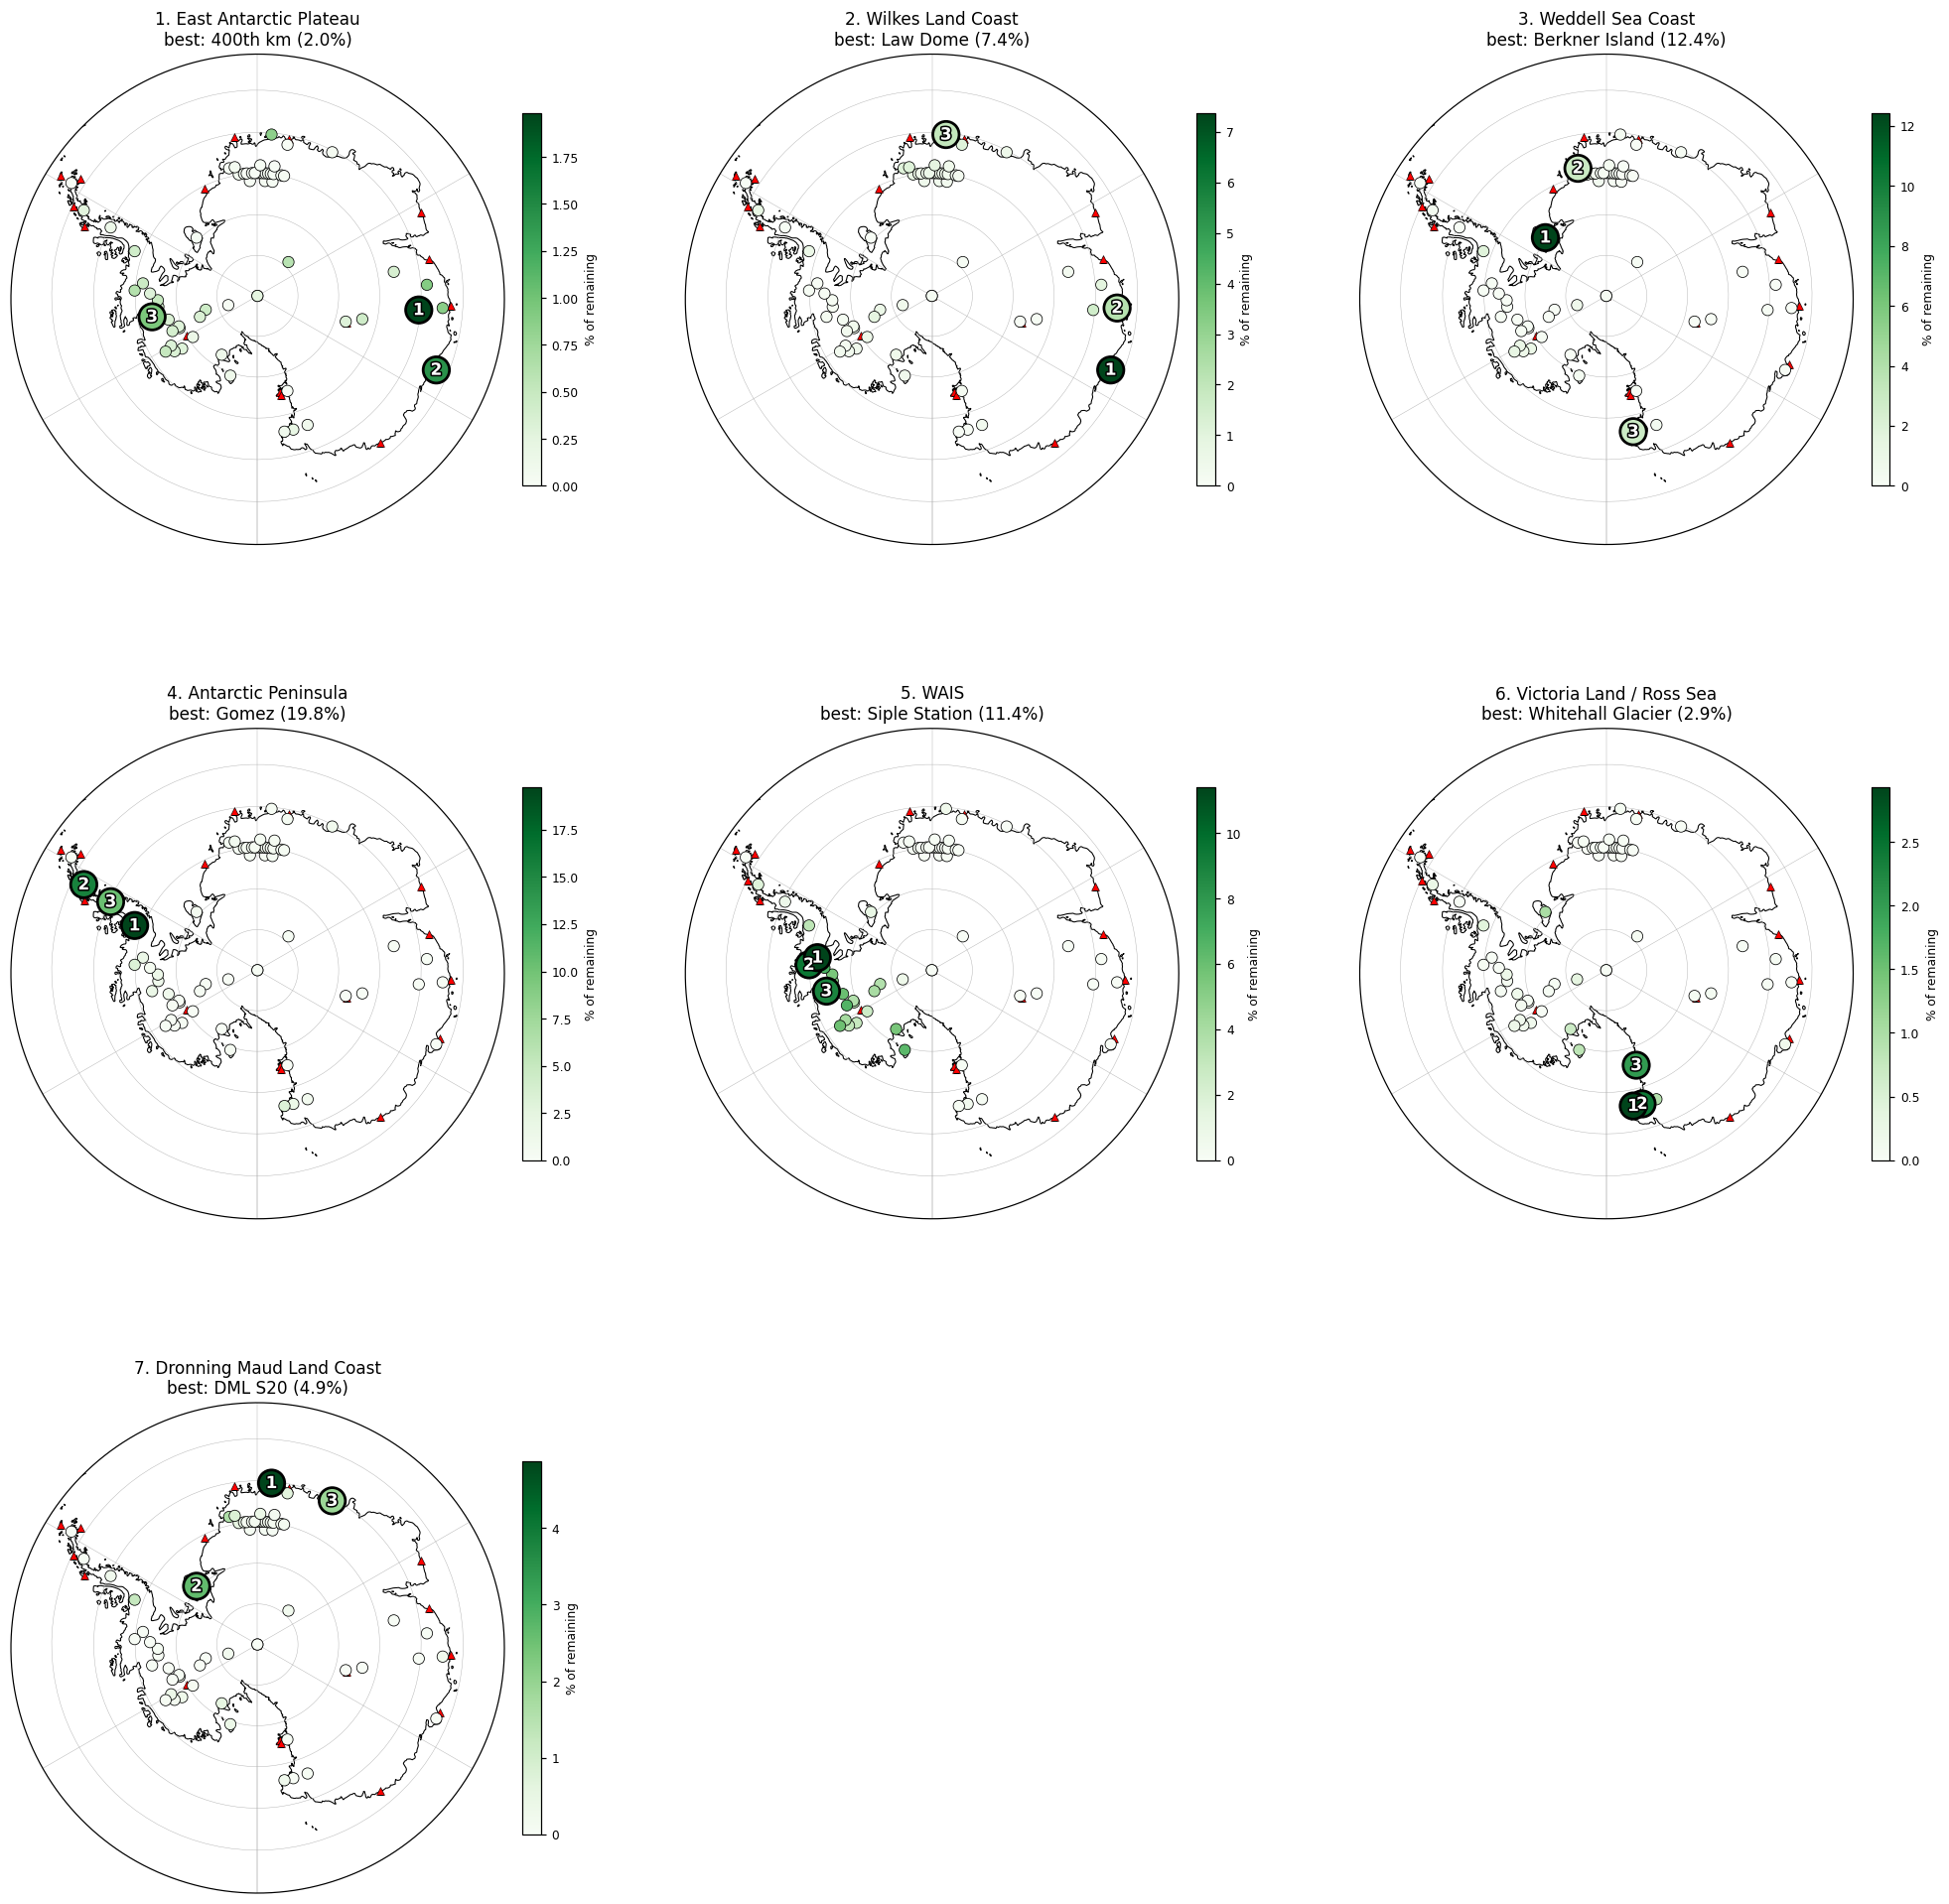

In [911]:
N_TOP = 3

import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# --- existing water-isotope core sites ---
cc = pd.read_csv(Path.home()/'DataFiles'/'WaterCoresCoords.csv', header=None,
                 names=['name', 'alt', 'lat', 'lon'])
cc['lat'] = cc.lat.astype(float)
cc['lon'] = np.mod(cc.lon.astype(float), 360.)
dmat = np.array([haversine_km(a, b, site_lat, site_lon)
                 for a, b in zip(cc.lat, cc.lon)])
cc['site'] = dmat.argmin(1)

CORE_SITES = sorted(set(cc.site))
core_mask  = np.zeros(N_POTENTIAL, bool); core_mask[CORE_SITES] = True
name_of = {}
for s_, n_ in zip(cc.site, cc.name):
    name_of.setdefault(int(s_), n_)
print(f'{len(cc)} cores -> {len(CORE_SITES)} unique cells\n')

# --- per region: assimilate AWS, evaluate every core ONCE, take the top 3 ---
res, rows = {}, []
for v, nm_ in P2K_NAMES.items():
    Jr = build_metric(Ye, mask=p2k_mask[v])
    ov = OptimalSensor(Jr, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0r = ov.J0var
    for i in AWS_SITES:
        ov.assimilate(int(i), Rval=R_AWS_ASSIM)
    v0r  = ov.metric_variance()
    dvr  = np.where(np.isfinite(ov.evaluate()), ov.evaluate(), np.nan)
    pctr = 100 * dvr / v0r
    # standalone ranking -- no sequential assimilation
    top = np.argsort(np.where(core_mask, pctr, -np.inf))[::-1][:N_TOP]
    res[v] = (pctr, top, J0r, v0r)
    for r_, k in enumerate(top, 1):
        rows.append(dict(region=f'{v} {nm_}', rank=r_, core=name_of[int(k)],
                         lat=site_lat[k], lon=site_lon[k], accum=accum_rate[k],
                         R=R_ICE_CORE[k], alone_pct=pctr[k]))

print(pd.DataFrame(rows).set_index(['region', 'rank']).round(2).to_string())

# --- 3 x 3 grid of maps, one per region ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
CMAP = plt.cm.Greens
fig = plt.figure(figsize=(19, 19))

for idx, v in enumerate(range(1, 8)):
    pctr, top, J0r, v0r = res[v]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.29, 0.29],
                      projection=SP)
    ax.set_extent([-180, 180, -90, -60], PL)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                    transform=ax.transAxes)
    ax.gridlines(linewidth=.3, color='0.7'); ax.coastlines(linewidth=.7)

    # per-panel scale: regional values span 2% (plateau) to 24% (Peninsula)
    VMAX = float(np.nanmax(pctr[CORE_SITES]))

    ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=26, c='red',
               edgecolors='k', lw=.4, transform=PL, zorder=2)
    other = [k for k in CORE_SITES if k not in set(top)]
    sc = ax.scatter(site_lon[other], site_lat[other], c=pctr[other], s=55,
                    cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.5,
                    transform=PL, zorder=3)

    o_ = np.arange(N_TOP)[::-1]              # paint worst-first, rank 1 on top
    ax.scatter(site_lon[top][o_], site_lat[top][o_], c=pctr[top][o_], s=300,
               cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=1.8,
               transform=PL, zorder=4)
    for rr, k in zip(range(N_TOP, 0, -1), top[::-1]):
        ax.annotate(str(rr), (site_lon[k], site_lat[k]),
                    xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                    fontsize=11, fontweight='bold', color='w',
                    zorder=5 + (N_TOP - rr)*.01,
                    path_effects=[pe.withStroke(linewidth=2, foreground='k')])

    cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
    cb.ax.tick_params(labelsize=8); cb.set_label('% of remaining', fontsize=8)
    ax.set_title(f'{v}. {P2K_NAMES[v]}\n'
                 f'best: {name_of[int(top[0])]} ({pctr[top[0]]:.1f}%)', fontsize=11)

plt.show()


In [912]:
"""
N_NEW = 5

import matplotlib.patheffects as pe
from matplotlib.lines import Line2D

# --- AWS station cells are the CANDIDATES for a new ice core ---
STN_SITES = sorted(set(aws_map.site))
stn_mask  = np.zeros(N_POTENTIAL, bool); stn_mask[STN_SITES] = True
stn_of = {}
for s_, n_ in zip(aws_map.site, aws_map.station):
    stn_of.setdefault(int(s_), n_)
print(f'{len(aws_map)} stations -> {len(STN_SITES)} unique cells')

# --- the full AWS network, for reference ---
o = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
J0 = o.J0var
for i in AWS_SITES:
    o.assimilate(int(i), Rval=R_AWS_ASSIM)
v0_full = o.metric_variance()

# A core in a cell whose station is already assimilated at R=0.05 is worth
# exactly 0 -- that cell's temperature is already pinned. So the core REPLACES
# the station: for each site, assimilate the OTHER 15 stations, then score a
# core there with its own R_ICE_CORE. Assimilated alone, not sequentially.
pct  = np.full(N_POTENTIAL, np.nan)
dabs = np.full(N_POTENTIAL, np.nan)
for k in STN_SITES:
    ok = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)
    for i in AWS_SITES:
        if int(i) != int(k):
            ok.assimilate(int(i), Rval=R_AWS_ASSIM)
    vk = ok.metric_variance()
    dabs[k] = ok.evaluate()[k]
    pct[k]  = 100 * dabs[k] / vk

st_alone = np.argsort(np.where(stn_mask, pct, -np.inf))[::-1][:N_NEW]

print(f'\nAIS metric variance {J0:.5f}; all {len(AWS_SITES)} stations leave '
      f'{v0_full:.5f} ({100*(1-v0_full/J0):.1f}% constrained)')
print(pd.DataFrame({'rank': range(1, N_NEW+1),
                    'station': [stn_of[int(s)] for s in st_alone], 'site': st_alone,
                    'lat': site_lat[st_alone], 'lon': site_lon[st_alone],
                    'accum': accum_rate[st_alone], 'R': R_ICE_CORE[st_alone],
                    'alone_pct': pct[st_alone]}).set_index('rank').round(2).to_string())
print(f'sum of the five: {pct[st_alone].sum():.2f}%  '
      f'(NOT what they would achieve together -- see the network cell)\n')
print('all stations:')
print(pd.DataFrame({'station': [stn_of[k] for k in STN_SITES], 'pct': pct[STN_SITES],
                    'accum': accum_rate[STN_SITES], 'R': R_ICE_CORE[STN_SITES]})
      .sort_values('pct', ascending=False).round(3).to_string(index=False))

# --- map ---
CMAP = plt.cm.Greens
VMAX = float(np.nanmax(pct[STN_SITES]))

SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(13, 12))
ax = plt.axes(projection=SP)
ax.set_extent([-180, 180, -90, -60], PL)
ax.gridlines(); ax.coastlines()

other = [k for k in STN_SITES if k not in set(st_alone)]
sc = ax.scatter(site_lon[other], site_lat[other], marker='^', c=pct[other], s=190,
                cmap=CMAP, vmin=0, vmax=VMAX, edgecolors='k', lw=.8,
                transform=PL, zorder=3)

order = np.arange(N_NEW)[::-1]              # paint worst-first, rank 1 on top
ax.scatter(site_lon[st_alone][order], site_lat[st_alone][order], marker='^',
           c=pct[st_alone][order], s=760, cmap=CMAP, vmin=0, vmax=VMAX,
           edgecolors='k', lw=2.2, transform=PL, zorder=4)

for r_, k in zip(range(N_NEW, 0, -1), st_alone[::-1]):
    ax.annotate(str(r_), (site_lon[k], site_lat[k]),
                xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                fontsize=14, fontweight='bold', color='w',
                zorder=5 + (N_NEW - r_) * 0.01,
                path_effects=[pe.withStroke(linewidth=2.5, foreground='k')])

cb = fig.colorbar(sc, ax=ax, shrink=.6, pad=.06)
cb.set_label('% of remaining AIS variance constrained by drilling a core here')
ax.legend(handles=[Line2D([], [], marker='^', ls='', c='0.6', mec='k',
                          label='AWS site'),
                   Line2D([], [], marker='^', ls='', c='0.6', mec='k', ms=15,
                          mew=2, label='top 5 individually')],
          loc='lower left', fontsize=9)
ax.set_title(f'Top {N_NEW} AWS sites to DRILL AN ICE CORE at, for AIS-wide temperature\n'
             f'given the other {len(AWS_SITES)-1} cells of the READER network', fontsize=13)
plt.show()
"""


"\nN_NEW = 5\n\nimport matplotlib.patheffects as pe\nfrom matplotlib.lines import Line2D\n\n# --- AWS station cells are the CANDIDATES for a new ice core ---\nSTN_SITES = sorted(set(aws_map.site))\nstn_mask  = np.zeros(N_POTENTIAL, bool); stn_mask[STN_SITES] = True\nstn_of = {}\nfor s_, n_ in zip(aws_map.site, aws_map.station):\n    stn_of.setdefault(int(s_), n_)\nprint(f'{len(aws_map)} stations -> {len(STN_SITES)} unique cells')\n\n# --- the full AWS network, for reference ---\no = OptimalSensor(J, Ye[:N_POTENTIAL], R_ICE_CORE)\nJ0 = o.J0var\nfor i in AWS_SITES:\n    o.assimilate(int(i), Rval=R_AWS_ASSIM)\nv0_full = o.metric_variance()\n\n# A core in a cell whose station is already assimilated at R=0.05 is worth\n# exactly 0 -- that cell's temperature is already pinned. So the core REPLACES\n# the station: for each site, assimilate the OTHER 15 stations, then score a\n# core there with its own R_ICE_CORE. Assimilated alone, not sequentially.\npct  = np.full(N_POTENTIAL, np.nan)\ndabs 

In [913]:
rows = []
for lbl, Jm in ([('AIS-wide', J)] +
                [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
                 for v in range(1, 8)]):
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0 = ob.J0var
    for i in AWS_SITES:
        ob.assimilate(int(i), Rval=R_AWS_ASSIM)
    v0 = ob.metric_variance()
    rows.append(dict(metric=lbl, var=J0, sd=np.sqrt(J0), remaining=v0,
                     resid_sd=np.sqrt(v0), constrained_pct=100*(1 - v0/J0)))

aws_var = pd.DataFrame(rows)
print(f'{len(AWS_SITES)}-cell READER AWS network at R = {R_AWS_ASSIM} K^2, '
      f'{nM} ensemble members\n')
print(aws_var.round(4).to_string(index=False))


16-cell READER AWS network at R = 0.36 K^2, 160 ensemble members

                     metric    var     sd  remaining  resid_sd  constrained_pct
                   AIS-wide 0.3183 0.5642     0.0481    0.2192          84.9033
  1. East Antarctic Plateau 0.4244 0.6514     0.0700    0.2646          83.4989
       2. Wilkes Land Coast 0.4651 0.6820     0.0662    0.2573          85.7651
       3. Weddell Sea Coast 0.6036 0.7769     0.3365    0.5801          44.2460
     4. Antarctic Peninsula 0.7379 0.8590     0.2068    0.4547          71.9758
                    5. WAIS 0.5494 0.7412     0.1630    0.4037          70.3312
6. Victoria Land / Ross Sea 0.4917 0.7012     0.1526    0.3906          68.9666
7. Dronning Maud Land Coast 0.3197 0.5655     0.0578    0.2404          81.9201


In [914]:
"""
import xarray as xr, scipy.io as sio

DLAT, DLON = 180/191., 1.25
_ccsm_lat = np.linspace(-90, 90, 192); _ccsm_lon = np.arange(288)*1.25
_ds  = xr.open_dataset(Path.home()/'DataFiles'/'ae3baa6a74f0aa315dc3de6f83298f0e.nc')
_t2m = _ds['t2m']
_elat, _elon = _t2m.latitude.values, _t2m.longitude.values
_yrs = _t2m.valid_time.dt.year.values
YR_R = np.arange(1979, 2025)

# the download is land-masked: NaN over ocean, so cell means are land-only
_land = ~np.isnan(_t2m.isel(valid_time=0).values)
_LA, _LO = np.meshgrid(_elat, _elon, indexing='ij')
_lidx, _llat, _llon = np.argwhere(_land), _LA[_land], _LO[_land]
print(f'ERA5 0.1 deg land pixels: {_land.sum()}')

_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']

def _ann(v):

    return np.array([np.nan if (_yrs == y).sum() < 12 else np.nanmean(v[_yrs == y])
                     for y in YR_R])

def _dvar(x, y):
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum() < 10:
        return np.nan, int(m.sum())
    d = x[m] - y[m]
    return float(np.var(d - d.mean(), ddof=1)), int(m.sum())

rows = []
for nm in _aws._fieldnames:
    r = getattr(_aws, nm)
    sla = float(r.lat); slo = ((float(r.lon) + 180) % 360) - 180
    ci = int(np.argmin(np.abs(_ccsm_lat - sla)))
    cj = int(np.argmin(np.abs(((_ccsm_lon - float(r.lon) + 180) % 360) - 180)))
    clat = _ccsm_lat[ci]; clon = ((_ccsm_lon[cj] + 180) % 360) - 180

    # every ERA5 land pixel inside the CCSM4 cell
    inbox = ((np.abs(_LA - clat) <= DLAT/2) &
             (np.abs(((_LO - clon + 180) % 360) - 180) <= DLON/2) & _land)
    # nearest ERA5 LAND pixel to the station itself
    dkm = haversine_km(sla, np.mod(slo, 360.), _llat, np.mod(_llon, 360.))
    p = _lidx[int(np.argmin(dkm))]

    a_pt = _ann(_t2m[:, p[0], p[1]].values)
    if inbox.sum():                       # Marambio / Halley have no land pixel
        cellm = np.nanmean(np.stack([_t2m[:, a, b].values
                                     for a, b in np.argwhere(inbox)]), axis=0)
    else:
        cellm = _t2m[:, p[0], p[1]].values
    a_cell = _ann(cellm)

    sy = np.asarray(r.year, int); stt = np.asarray(r.T_AWS, float)
    a_stn = np.array([stt[sy == y][0] if (sy == y).any() else np.nan for y in YR_R])

    R_repr, _ = _dvar(a_pt, a_cell)       # pure point-vs-cell representativeness
    R_dir, n  = _dvar(a_stn, a_cell)      # total station-vs-cell error  <- use this
    m = np.isfinite(a_stn) & np.isfinite(a_cell)
    rows.append(dict(station=nm, lat=sla, lon=slo, elev=int(r.elev),
                     npix=int(inbox.sum()), pt_km=round(float(dkm.min()), 1),
                     sd_stn=float(np.nanstd(a_stn[m], ddof=1)),
                     sd_cell=float(np.nanstd(a_cell[m], ddof=1)),
                     corr=float(np.corrcoef(a_stn[m], a_cell[m])[0, 1]),
                     R_repr=R_repr, R_direct=R_dir, n=n))

aws_R = pd.DataFrame(rows)
print(aws_R.round(3).to_string(index=False))
print(f'\nR_repr   (ERA5 point vs ERA5 cell): median {aws_R.R_repr.median():.3f} K^2')
print(f'R_direct (station vs ERA5 cell):    median {aws_R.R_direct.median():.3f} K^2, '
      f'range {aws_R.R_direct.min():.3f}..{aws_R.R_direct.max():.3f}')

# --- per-cell R, averaging stations that share a CCSM4 cell ---
aws_R['site'] = aws_R.station.map(dict(zip(aws_map.station, aws_map.site)))
R_AWS_EMP = {int(k): float(v)
             for k, v in aws_R.dropna(subset=['site']).groupby('site').R_direct.mean().items()}
R_AWS_DEFAULT = float(np.median(list(R_AWS_EMP.values())))
print(f'\nempirical R for {len(R_AWS_EMP)}/{len(AWS_SITES)} cells; '
      f'fallback {R_AWS_DEFAULT:.3f}')

# --- what it changes ---
out = []
for lbl, Jm in ([('AIS-wide', J)] +
                [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
                 for v in range(1, 8)]):
    row = {'metric': lbl}
    for tag, fn in [('R=0.05', lambda i: R_AWS_ASSIM),
                    ('R=empirical', lambda i: R_AWS_EMP.get(int(i), R_AWS_DEFAULT)),
                    ('R=0.5', lambda i: 0.5)]:
        ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
        for i in AWS_SITES:
            ob.assimilate(int(i), Rval=fn(i))
        row[tag] = 100 * (1 - ob.metric_variance() / ob.J0var)
    out.append(row)
print('\n% of variance constrained by the 16-cell AWS network')
print(pd.DataFrame(out).round(2).to_string(index=False))
"""

"\nimport xarray as xr, scipy.io as sio\n\nDLAT, DLON = 180/191., 1.25\n_ccsm_lat = np.linspace(-90, 90, 192); _ccsm_lon = np.arange(288)*1.25\n_ds  = xr.open_dataset(Path.home()/'DataFiles'/'ae3baa6a74f0aa315dc3de6f83298f0e.nc')\n_t2m = _ds['t2m']\n_elat, _elon = _t2m.latitude.values, _t2m.longitude.values\n_yrs = _t2m.valid_time.dt.year.values\nYR_R = np.arange(1979, 2025)\n\n# the download is land-masked: NaN over ocean, so cell means are land-only\n_land = ~np.isnan(_t2m.isel(valid_time=0).values)\n_LA, _LO = np.meshgrid(_elat, _elon, indexing='ij')\n_lidx, _llat, _llon = np.argwhere(_land), _LA[_land], _LO[_land]\nprint(f'ERA5 0.1 deg land pixels: {_land.sum()}')\n\n_aws = sio.loadmat(AWS_MAT, squeeze_me=True, struct_as_record=False)['dataAWS']\n\ndef _ann(v):\n\n    return np.array([np.nan if (_yrs == y).sum() < 12 else np.nanmean(v[_yrs == y])\n                     for y in YR_R])\n\ndef _dvar(x, y):\n    m = np.isfinite(x) & np.isfinite(y)\n    if m.sum() < 10:\n        return 

In [915]:
R_aws, R_AWS_SITE = build_R_aws()
print(f'R_AWS_MODE = {R_AWS_MODE}')
print('R per AWS cell:', {k: round(R_aws(k), 3) for k in AWS_SITES})


R_AWS_MODE = constant
R per AWS cell: {0: 0.0, 3361: 0.0, 3542: 0.0, 3876: 0.0, 4441: 0.0, 5350: 0.0, 5366: 0.0, 5615: 0.0, 5622: 0.0, 5737: 0.0, 5743: 0.0, 5756: 0.0, 5766: 0.0, 5784: 0.0, 5791: 0.0, 5792: 0.0}


In [916]:
# ============================================================================
# AWS observation error variance R (K^2)
#   'per_station' -- triple-collocation estimates, station / ERA5 cell mean /
#                    RACMO cell mean, annual means 1979-2024, floored at 0.02.
#                    Includes point-vs-gridcell representativeness, which is
#                    what R needs to hold, so it is NOT a statement about
#                    instrument quality.
#   'constant'    -- one value for every station, R_AWS_CONST.
# ============================================================================
R_AWS_MODE  = 'per_station'      # 'per_station' | 'constant'
R_AWS_CONST = 0.20               # used only when R_AWS_MODE == 'constant'

R_AWS_TC_STATION = {             # station name -> R, K^2      (raw TC / direct)
    'FaradayVernadsky': 0.731,   # TC +0.731   direct 0.745
    'Rothera':          0.674,   # TC +0.674   direct 0.614
    'Byrd':             0.363,   # TC +0.363   direct 0.362
    'Halley':           0.350,   # TC +0.350   direct 0.592
    'ScottBase':        0.301,   # TC +0.301   direct 0.410
    'AmundsenScott':    0.295,   # TC +0.295   direct 0.361
    'McMurdo':          0.288,   # TC +0.288   direct 0.327
    'Marambio':         0.228,   # TC +0.228   direct 0.406
    'Vostok':           0.215,   # TC +0.215   direct 0.369
    'DDU':              0.089,   # TC +0.089   direct 0.130
    'Novolazarevskaya': 0.087,   # TC +0.087   direct 0.599
    'Neumayer':         0.054,   # TC +0.054   direct 0.260
    'Bellingshausen':   0.038,   # TC +0.038   direct 0.037
    'Casey':            0.027,   # TC +0.027   direct 0.065
    'Davis':            0.027,   # TC +0.027   direct 0.056
    'Mirny':            0.023,   # TC +0.023   direct 0.052
    'Mawson':           0.020,   # TC +0.011   direct 0.039  (floored)
}
R_AWS_DEFAULT = 0.215            # median, for any station not in the table

def build_R_aws():
    """Return (R_aws, R_AWS_SITE). Needs aws_map."""
    t = aws_map.assign(R=aws_map.station.map(R_AWS_TC_STATION))
    site_R = {int(k): float(v) for k, v in
              t.dropna(subset=['R']).groupby('site').R.mean().items()}
    if R_AWS_MODE == 'per_station':
        f = lambda i: site_R.get(int(i), R_AWS_DEFAULT)
    elif R_AWS_MODE == 'constant':
        f = lambda i: R_AWS_CONST
    else:
        raise ValueError(R_AWS_MODE)
    return f, site_R

if R_AWS_MODE == 'constant':
    R_aws, R_AWS_SITE = (lambda i: R_AWS_CONST), {}
elif 'aws_map' in dir():                 # re-runs after aws_map exists resolve now
    R_aws, R_AWS_SITE = build_R_aws()
else:                                    # first pass, before aws_map is built
    def R_aws(i):
        raise RuntimeError('call R_aws, R_AWS_SITE = build_R_aws() after aws_map')
    R_AWS_SITE = {}

print(f'R_AWS_MODE = {R_AWS_MODE}' +
      (f'  (R = {R_AWS_CONST} K^2 everywhere)' if R_AWS_MODE == 'constant'
       else f'  ({len(R_AWS_TC_STATION)} stations, median {R_AWS_DEFAULT} K^2)') +
      ('' if R_AWS_SITE or R_AWS_MODE == 'constant' else '  [pending build_R_aws()]'))


R_AWS_MODE = per_station  (17 stations, median 0.215 K^2)


ENSEMBLE=MRE  nM=160  DOF=159  Jvar=0.31829  network capped at 79 obs (50% of DOF)

greedy sequential to 95% of TOTAL variance, on top of the AWS network, cap 400

                     metric  aws_base  n  reached  n90  n93  n95  dof_pct  capped   lat1   lon1  accum1
                   AIS-wide     88.82 63    94.56    4   25   -1    49.69    True -74.92 282.50  672.01
  1. East Antarctic Plateau     87.54 63    92.88   10   -1   -1    49.69    True -73.98 243.75 1043.56
       2. Wilkes Land Coast     91.69  6    95.12    1    2    6    13.84   False -68.32 145.00  587.87
       3. Weddell Sea Coast     50.06 63    93.41   30   57   -1    49.69    True -78.69 320.00  298.71
     4. Antarctic Peninsula     68.96 12    95.35    5    8   12    17.61   False -73.04 288.75  999.83
                    5. WAIS     71.66 38    95.02   10   22   38    33.96   False -73.98 241.25 1148.44
6. Victoria Land / Ross Sea     72.23 63    91.53   46   -1   -1    49.69    True -78.69 162.50  295.38
7. D

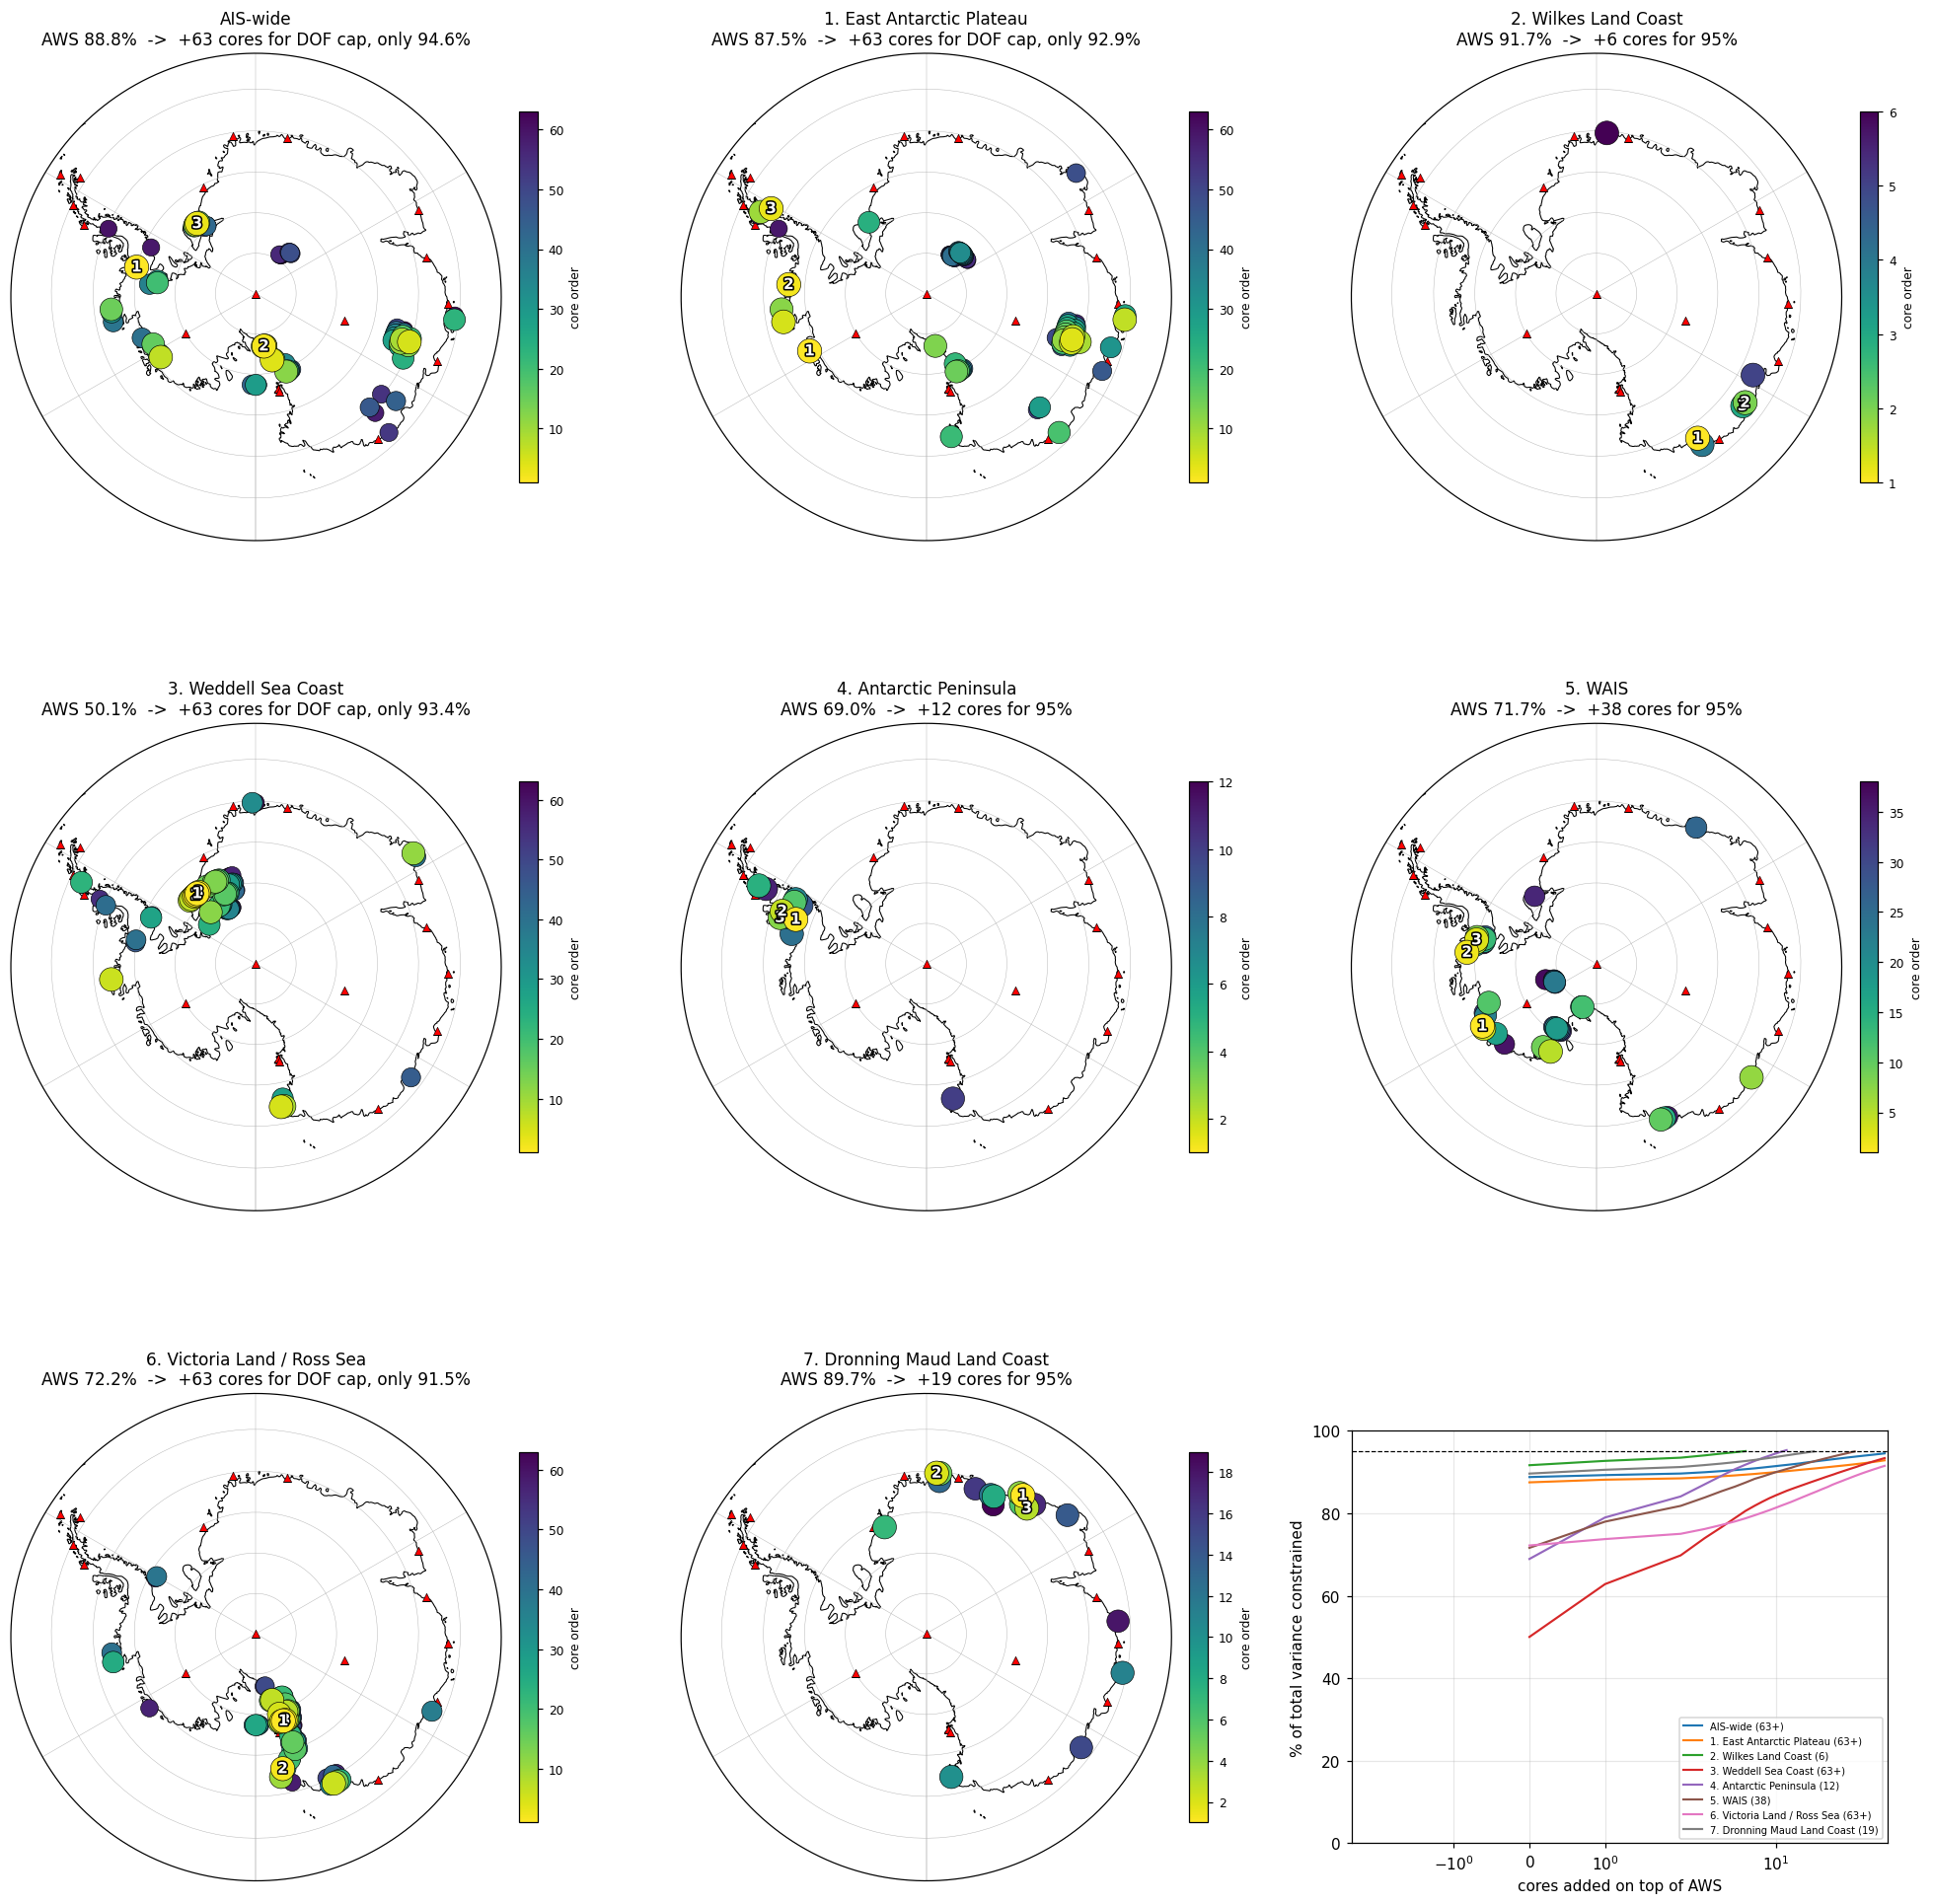

In [917]:
# ---- toggles ----------------------------------------------------------
THRESH    = 0.95     # target fraction of the metric's TOTAL variance
NMAX      = 400      # hard cap on network size
USE_AWS   = True     # start from the assimilated AWS network
DOF_LIMIT = 0.50     # stop early past this fraction of (nM - 1)
REQUIRE_ENSEMBLE = 'MRE'    # None to skip the check
# -----------------------------------------------------------------------

import matplotlib.patheffects as pe

if REQUIRE_ENSEMBLE is not None and ENSEMBLE != REQUIRE_ENSEMBLE:
    raise RuntimeError(f'kernel holds ENSEMBLE={ENSEMBLE} (nM={nM}); set '
                       f'ENSEMBLE={REQUIRE_ENSEMBLE!r} and re-run the loader cell')
DOF_MAX = int(DOF_LIMIT * (nM - 1))
print(f'ENSEMBLE={ENSEMBLE}  nM={nM}  DOF={nM-1}  Jvar={J.var(ddof=1):.5f}  '
      f'network capped at {DOF_MAX} obs ({100*DOF_LIMIT:.0f}% of DOF)\n')

mets = ([('AIS-wide', J)] +
        [(f'{v}. {P2K_NAMES[v]}', build_metric(Ye, mask=p2k_mask[v]))
         for v in range(1, 8)])

res, rows = {}, []
for lbl, Jm in mets:
    ob = OptimalSensor(Jm, Ye[:N_POTENTIAL], R_ICE_CORE)
    J0 = ob.J0var
    n_bg = 0
    if USE_AWS:
        for i in AWS_SITES:
            ob.assimilate(int(i), Rval=R_aws(i))
        n_bg = len(AWS_SITES)
    base = 100 * (1 - ob.metric_variance() / J0)   # what AWS already gives
    st, cum = [], []
    hit_dof = False
    for _ in range(NMAX):                          # greedy sequential, as in DASH
        if n_bg + len(st) >= DOF_MAX:
            hit_dof = True
            break
        dv = ob.evaluate()
        dv = np.where(np.isfinite(dv), dv, -np.inf)
        for k in st:
            dv[k] = -np.inf
        b = int(np.argmax(dv))
        if dv[b] <= 0:
            break
        v = ob.assimilate(b)
        st.append(b); cum.append(100 * (1 - v / J0))   # % of TOTAL, not remaining
        if cum[-1] >= 100 * THRESH:
            break
    st, cum = np.array(st), np.array(cum)
    res[lbl] = (st, cum, J0, base, hit_dof)
    hit = lambda p: (int(np.argmax(cum >= p)) + 1) if (cum >= p).any() else -1
    rows.append(dict(metric=lbl, aws_base=base, n=len(st), reached=cum[-1],
                     n90=hit(90), n93=hit(93), n95=hit(95),
                     dof_pct=100*(n_bg + len(st))/(nM - 1),
                     capped=hit_dof, lat1=site_lat[st[0]], lon1=site_lon[st[0]],
                     accum1=accum_rate[st[0]]))

print(f'greedy sequential to {100*THRESH:.0f}% of TOTAL variance, '
      f'{"on top of the AWS network" if USE_AWS else "ice cores only"}, cap {NMAX}\n')
print(pd.DataFrame(rows).round(2).to_string(index=False))
if any(r['capped'] for r in rows):
    print('\n*** capped rows stopped at the DOF limit: the true count exceeds what '
          f'{nM} members can resolve ***')

# --- 3x3: seven regions + AIS, with the cumulative curves in the last slot ---
SP, PL = ccrs.SouthPolarStereo(), ccrs.PlateCarree()
fig = plt.figure(figsize=(19, 19))

for idx, (lbl, _) in enumerate(mets):
    st, cum, J0, base, hit_dof = res[lbl]
    r_, c_ = divmod(idx, 3)
    ax = fig.add_axes([0.02 + c_*0.325, 0.68 - r_*0.325, 0.29, 0.29], projection=SP)
    ax.set_extent([-180, 180, -90, -60], PL)
    th = np.linspace(0, 2*np.pi, 200)
    ax.set_boundary(mpath.Path(np.stack([np.cos(th), np.sin(th)], 1)*.5+.5),
                    transform=ax.transAxes)
    ax.gridlines(linewidth=.3, color='0.7'); ax.coastlines(linewidth=.7)

    if USE_AWS:
        ax.scatter(aws_map.lon, aws_map.lat, marker='^', s=30, c='red',
                   edgecolors='k', lw=.4, transform=PL, zorder=2)
    rank = np.arange(1, len(st) + 1)
    o_ = np.arange(len(st))[::-1]              # draw last-picked first
    sc = ax.scatter(site_lon[st][o_], site_lat[st][o_], c=rank[o_],
                    s=np.clip(260 - 2.2*rank, 18, 260)[o_], cmap='viridis_r',
                    edgecolors='k', lw=.4, transform=PL, zorder=3)
    for rr in (3, 2, 1):
        if len(st) >= rr:
            k = st[rr-1]
            ax.annotate(str(rr), (site_lon[k], site_lat[k]),
                        xycoords=PL._as_mpl_transform(ax), ha='center', va='center',
                        fontsize=10, fontweight='bold', color='w', zorder=6,
                        path_effects=[pe.withStroke(linewidth=2, foreground='k')])
    cb = fig.colorbar(sc, ax=ax, shrink=.62, pad=.03)
    cb.ax.tick_params(labelsize=8); cb.set_label('core order', fontsize=8)
    tail = f'{100*THRESH:.0f}%' if not hit_dof else f'DOF cap, only {cum[-1]:.1f}%'
    ax.set_title(f'{lbl}\nAWS {base:.1f}%  ->  +{len(st)} cores for {tail}',
                 fontsize=11)

ax = fig.add_axes([0.02 + 2*0.325, 0.68 - 2*0.325 + 0.045, 0.26, 0.20])
for lbl, _ in mets:
    st, cum, J0, base, hit_dof = res[lbl]
    ax.plot(np.arange(0, len(cum)+1), np.concatenate([[base], cum]), lw=1.4,
            label=f'{lbl} ({len(st)}{"+" if hit_dof else ""})')
ax.axhline(100*THRESH, color='k', ls='--', lw=.8)
ax.set_xscale('symlog'); ax.set_xlabel('cores added on top of AWS')
ax.set_ylabel('% of total variance constrained'); ax.set_ylim(0, 100)
ax.legend(fontsize=6.5, loc='lower right'); ax.grid(alpha=.3)
plt.show()
